# Business Understanding


## Data Understanding


In [24]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
df = pd.read_csv("/content/train.csv")
df.head()

/tmp/ipykernel_963/1548380323.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/train.csv")


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [26]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,9985
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,0


### Data Cleaning

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob



> Seperti yang bisa Anda lihat pada gambar di atas, terdapat beberapa feature yang memiliki tipe data yang tidak sesuai dengan deskripsinya. Hal ini berarti terdapat beberapa feature yang memiliki nilai yang salah (invalid value). Untuk mengecek hal tersebut, kita bisa menggunakan method describe() yang disediakan oleh pandas. Berikut merupakan contoh penggunaannya.



In [28]:
df. describe(include="all")

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,84998.000000,100000.000000,...,100000,100000,100000.000000,90970,100000,100000.000000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,NaN,NaN,...,4,13178,NaN,404,3,NaN,91049,7,98792,3
top,0x25fd5,CUS_0x942c,January,Stevex,38,#F%$D@*&8,_______,36585.12,NaN,NaN,...,Standard,1360.45,NaN,15 Years and 11 Months,Yes,NaN,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,NaN,NaN,...,36479,24,NaN,446,52326,NaN,4305,25513,9,53174
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4194.170850,17.091280,...,NaN,NaN,32.285173,NaN,NaN,1403.118217,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3183.686167,117.404834,...,NaN,NaN,5.116875,NaN,NaN,8306.041270,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,303.645417,-1.000000,...,NaN,NaN,20.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1625.568229,3.000000,...,NaN,NaN,28.052567,NaN,NaN,30.306660,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3093.745000,6.000000,...,NaN,NaN,32.305784,NaN,NaN,69.249473,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5957.448333,7.000000,...,NaN,NaN,36.496663,NaN,NaN,161.224249,NaN,NaN,NaN,NaN




> Jika Anda perhatikan, terdapat beberapa nilai yang bermasalah seperti “__10000__”, “__-333333333333333333333333333__”, dll. Nilai inilah yang perlu kita bersihkan untuk mengubah tipe data dari feature tersebut. Untuk melakukan hal ini, kita membutuhkan helper function berikut.



In [29]:
def return_null(val):
    if isinstance(val, str) and "__" in val:
        return np.NaN
    elif isinstance(val, str) and "_" in val:
        return np.NaN
    else:
        return val



> Helper function di atas akan mengubah semua nilai yang mengandung “_” atau “__” menjadi sebuah np.NaN yang merupakan missing value. Berikut merupakan contoh kode untuk menggunakan helper function tersebut.



In [30]:
new_df = df.copy()
invalid_numerical_columns = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

def return_null(val):
    if isinstance(val, str) and "__" in val:
        return np.nan
    elif isinstance(val, str) and "_" in val:
        return np.nan
    else:
        return val

for col in invalid_numerical_columns:
    new_df[col] = new_df[col].apply(return_null)
    new_df[col] = new_df[col].astype('float')

new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       95061 non-null   float64
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             93020 non-null   float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               95215 non-null   float64
 13  Type_of_Loan              88592 non-null   ob



> Nah, bisa Anda lihat sebagian besar feature telah memiliki tipe data yang sesuai, kecuali feature Credit_History_Age. Untuk memperbaikinya, kita memerlukan helper function lain seperti berikut.



In [31]:
import re

def cal_history_age(val):
    try:
        year, month = 0, 0
        if re.search('year', val, re.IGNORECASE):
            year = int(re.findall('\d+', val)[0])
        if re.search('month', val, re.IGNORECASE):
            month = int(re.findall('\d+', val)[1])
        return year*12+month
    except:
        return np.nan

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_963/1699215887.py:7: SyntaxWarning: invalid escape sequence '\d'
  year = int(re.findall('\d+', val)[0])
/tmp/ipykernel_963/1699215887.py:9: SyntaxWarning: invalid escape sequence '\d'
  month = int(re.findall('\d+', val)[1])




> Sederhananya, helper function tersebut akan mengambil komponen tahun dan bulan yang terdapat dalam data Credit_History_Age. Proses ini dilakukan dengan menggunakan teknik Regular expression (regex) untuk mencari pola karakter yang tepat (Python Regular Expressions). Helper function ini akan mengembalikan total bulan dari riwayat kredit pelanggan dan nilai np.NaN jika gagal. Berikut merupakan contoh penggunaan dari helper function tersebut.



In [32]:
new_df['Credit_History_Age'] = new_df['Credit_History_Age'].apply(cal_history_age)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       95061 non-null   float64
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             93020 non-null   float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               95215 non-null   float64
 13  Type_of_Loan              88592 non-null   ob



> sekarang kita telah berhasil memperbaiki tipe data dari seluruh feature numerik. Sekarang kita coba memilih feature numerik mana yang akan digunakan. Proses ini biasanya dilakukan berdasarkan background knowledge dan atau hasil EDA (kita akan melakukannya pada materi berikutnya). Berdasarkan background knowledge, kita mengetahui bahwa feature Annual_Income dan Monthly_Inhand_Salary merepresentasikan hal yang sama yaitu pendapatan yang diperoleh setiap pelanggan. Oleh karena itu, kita hanya akan memilih salah satu dari keduanya. Berikut merupakan contoh kode untuk menghilangkan (drop) feature Annual_Income serta beberapa feature lain yang tidak dibutuhkan seperti Name dan SSN.



In [33]:
new_df.drop([col for col in ["ID", "Name", "SSN", "Annual_Income"] if col in new_df.columns], axis=1, inplace=True)



> Setelah menghilangkan beberapa feature tersebut, kini saatnya kita melanjutkan proses pembersihan data. Pada proyek ini, kita akan mulai dengan membersihkan feature numerik terlebih dahulu. Tahap pertama, kita akan memeriksa rangkuman parameter statistik dari kolom tersebut menggunakan kode di bawah ini.



In [34]:
numerical_columns = [
    'Age',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Credit_History_Age'
]

new_df[numerical_columns].describe()

,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age
count,95061.000000,84998.000000,100000.000000,100000.00000,100000.000000,95215.000000,100000.000000,90254.000000,97909.000000,98035.000000,98991.000000,100000.000000,100000.000000,91216.000000,98791.000000,90970.000000
mean,110.934505,4194.170850,17.091280,22.47443,72.466040,2.780339,21.068780,31.033051,10.389025,27.754251,1426.503700,32.285173,1403.118217,195.539456,402.551258,221.195405
std,689.407864,3183.686167,117.404834,129.05741,466.422621,62.500940,14.860104,226.955758,6.789496,193.177339,1155.045753,5.116875,8306.041270,199.564527,213.925499,99.741364
min,-500.000000,303.645417,-1.000000,0.00000,1.000000,-100.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,0.000000,0.000000,0.007760,1.000000
25%,24.000000,1625.568229,3.000000,4.00000,8.000000,1.000000,10.000000,9.000000,5.320000,3.000000,566.080000,28.052567,30.306660,72.236692,270.106630,144.000000
50%,33.000000,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,14.000000,9.400000,6.000000,1166.370000,32.305784,69.249473,128.954538,336.731225,219.000000
75%,42.000000,5957.448333,7.000000,7.00000,20.000000,5.000000,28.000000,18.000000,14.870000,9.000000,1948.200000,36.496663,161.224249,236.815814,470.262938,302.000000
max,8698.000000,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,4397.000000,36.970000,2597.000000,4998.070000,50.000000,82331.000000,1977.326102,1602.040519,404.000000




> Nah, berdasarkan hasil tersebut terlihat beberapa nilai yang tidak biasa seperti umur -500 tahun, jumlah akun bank sebanyak 1798, dll. Nilai tersebut perlu divalidasi terlebih dahulu. Berikut merupakan contoh kode untuk memvalidasi nilai tersebut.



In [35]:
def check_invalid_values(df, invalid_value, column):
    df = df.copy()
    customer_id = df[(df[column] == invalid_value)].groupby(by="Customer_ID", as_index=False)["Num_Bank_Accounts"].mean()
    print(df[df.Customer_ID.isin(customer_id.Customer_ID)])

check_invalid_values(new_df, -500, "Age")

      Customer_ID     Month    Age Occupation  Monthly_Inhand_Salary  \
0       CUS_0xd40   January   23.0  Scientist            1824.843333   
1       CUS_0xd40  February   23.0  Scientist                    NaN   
2       CUS_0xd40     March -500.0  Scientist                    NaN   
3       CUS_0xd40     April   23.0  Scientist                    NaN   
4       CUS_0xd40       May   23.0  Scientist            1824.843333   
...           ...       ...    ...        ...                    ...   
99963  CUS_0x372c     April -500.0     Lawyer                    NaN   
99964  CUS_0x372c       May   18.0     Lawyer            3468.315833   
99965  CUS_0x372c      June   19.0     Lawyer            3468.315833   
99966  CUS_0x372c      July   19.0     Lawyer            3468.315833   
99967  CUS_0x372c    August   19.0     Lawyer            3468.315833   

       Num_Bank_Accounts  Num_Credit_Card  Interest_Rate  Num_of_Loan  \
0                      3                4              3      



> Kode tersebut akan menghasilkan output seperti pada gambar di bawah ini yang menunjukkan data pelanggan dengan umur -500 tahun. Anda dapat menyesuaikan kode di atas untuk melihat data yang mengandung nilai yang tidak biasa pada feature yang lain.



Setelah melakukan validasi terhadap beberapa nilai yang tidak biasa tersebut, Anda mengetahui bahwa nilai tersebut merupakan nilai yang tidak valid. Jika melakukan validasi secara teliti, Anda akan menemukan beberapa invalid value pada beberapa feature seperti berikut.

1. Pada kolom Age, semua nilai yang lebih kecil dari 0 atau lebih besar dari 90 merupakan invalid value.
2. Pada kolom Num_Bank_Accounts, semua nilai yang lebih kecil dari 0 atau lebih besar dari 15 merupakan invalid value.
3. Pada kolom Num_Credit_Card, semua nilai yang lebih kecil dari 0 atau lebih besar dari 15 merupakan invalid value.
4. Pada kolom Interest_Rate, semua nilai yang lebih besar dari 50 merupakan invalid value.
5. Pada kolom Num_of_Loan, semua nilai yang lebih kecil dari 0 atau lebih besar dari 10 merupakan invalid value.
6. Pada kolom Delay_from_due_date, semua nilai yang lebih kecil dari 0 merupakan invalid value.
7. Pada kolom Num_of_Delayed_Paymen, semua nilai yang lebih kecil dari 0 atau lebih besar dari 30 merupakan invalid value.
8. Pada kolom Changed_Credit_Limit, semua nilai yang lebih kecil dari 0 merupakan invalid value.
9. Pada kolom Num_Credit_Inquiries, semua nilai yang lebih besar dari 25 merupakan invalid value.
10. Pada kolom Total_EMI_per_month, semua nilai yang lebih besar dari 1400 merupakan invalid value.


> Tentu, kita perlu memperbaiki seluruh nilai tersebut sebelum diolah lebih lanjut. Untuk memperbaikinya, kita akan mengubah sebagian besar invalid value sebagai missing value atau nilai nol sesuai dengan background knowledge dari permasalahan ini. Berikut merupakan contoh kode yang dapat Anda gunakan.



In [36]:
import pandas as pd
import numpy as np
import re

# Re-create df (from w6-AMjfAyGN8)
df = pd.read_csv("/content/train.csv")

# Helper function return_null (from -HiDIp4E2cH6 or 4V8vzoA-3CSw)
def return_null(val):
    if isinstance(val, str) and "__" in val:
        return np.nan
    elif isinstance(val, str) and "_" in val:
        return np.nan
    else:
        return val

# Helper function cal_history_age (from vNtUtbQV3Zkc)
def cal_history_age(val):
    try:
        year, month = 0, 0
        if re.search('year', val, re.IGNORECASE):
            year = int(re.findall(r'\d+', val)[0])
        if re.search('month', val, re.IGNORECASE):
            month = int(re.findall(r'\d+', val)[1])
        return year*12+month
    except:
        return np.nan

# Initial new_df creation and invalid_numerical_columns definition (from 4V8vzoA-3CSw)
new_df = df.copy()
invalid_numerical_columns = [
    'Age',
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Outstanding_Debt',
    'Amount_invested_monthly',
    'Monthly_Balance'
]

for col in invalid_numerical_columns:
    new_df[col] = new_df[col].apply(return_null)
    new_df[col] = new_df[col].astype('float')

# Apply cal_history_age (from UHgOiEpU3uP6)
new_df['Credit_History_Age'] = new_df['Credit_History_Age'].apply(cal_history_age)

# Drop columns (from -Kg7nAS838Vw)
new_df.drop([col for col in ["ID", "Name", "SSN", "Annual_Income"] if col in new_df.columns], axis=1, inplace=True)

# Define numerical_columns (from HaUD9XS-4NK0)
numerical_columns = [
    'Age',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Credit_History_Age'
]

# Original code from CkowI73qByM3
new_df["Age"] = new_df.Age.apply(lambda x: np.nan if x<0 or x>90 else x)
new_df["Num_Bank_Accounts"] = new_df.Num_Bank_Accounts.apply(lambda x: np.nan if x<0 or x>15 else x)
new_df["Num_Credit_Card"] = new_df.Num_Credit_Card.apply(lambda x: np.nan if x<0 or x>15 else x)
new_df["Interest_Rate"] = new_df.Interest_Rate.apply(lambda x: np.nan if x>50 else x)
new_df["Num_of_Loan"] = new_df.Num_of_Loan.apply(lambda x: np.nan if x<0 or x>10 else x)
new_df["Delay_from_due_date"] = new_df.Delay_from_due_date.apply(lambda x: 0.0 if x<0 else x)
new_df["Num_of_Delayed_Payment"] = new_df.Num_of_Delayed_Payment.apply(lambda x: np.nan if x<0 or x>30 else x)
new_df["Changed_Credit_Limit"] = new_df.Changed_Credit_Limit.apply(lambda x: 0.0 if x<0 else x)
new_df["Num_Credit_Inquiries"] = new_df.Num_Credit_Inquiries.apply(lambda x: np.nan if x>25 else x)
new_df["Total_EMI_per_month"] = new_df.Total_EMI_per_month.apply(lambda x: np.nan if x>1400 else x)

new_df[numerical_columns].describe(include="all")

/tmp/ipykernel_963/510315510.py:6: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/train.csv")


,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age
count,92365.000000,84998.000000,98664.000000,97732.000000,97966.000000,90892.000000,100000.000000,88915.000000,97909.000000,96385.000000,98991.000000,100000.000000,96781.000000,91216.000000,98791.000000,90970.000000
mean,33.314145,4194.170850,5.368980,5.533612,14.531603,3.534172,21.081910,13.424529,10.427352,5.781117,1426.503700,32.285173,106.036989,195.539456,402.551258,221.195405
std,10.770143,3183.686167,2.592451,2.068336,8.739748,2.447488,14.840204,6.207212,6.720510,3.860712,1155.045753,5.116875,122.739064,199.564527,213.925499,99.741364
min,14.000000,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.230000,20.000000,0.000000,0.000000,0.007760,1.000000
25%,24.000000,1625.568229,3.000000,4.000000,7.000000,2.000000,10.000000,9.000000,5.320000,3.000000,566.080000,28.052567,29.270265,72.236692,270.106630,144.000000
50%,33.000000,3093.745000,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.400000,5.000000,1166.370000,32.305784,66.413778,128.954538,336.731225,219.000000
75%,42.000000,5957.448333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.870000,8.000000,1948.200000,36.496663,146.701253,236.815814,470.262938,302.000000
max,56.000000,15204.633333,11.000000,15.000000,34.000000,9.000000,67.000000,28.000000,36.970000,17.000000,4998.070000,50.000000,1396.000000,1977.326102,1602.040519,404.000000


In [37]:
numerical_columns = [
    'Age',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Credit_History_Age'
]

new_df[numerical_columns].isnull().sum()

,0
Age,7635
Monthly_Inhand_Salary,15002
Num_Bank_Accounts,1336
Num_Credit_Card,2268
Interest_Rate,2034
Num_of_Loan,9108
Delay_from_due_date,0
Num_of_Delayed_Payment,11085
Changed_Credit_Limit,2091
Num_Credit_Inquiries,3615




> Sesuai ekspektasi, kita memiliki cukup banyak missing value. Untuk membersihkan missing value tersebut, kita perlu membuat strategi berdasarkan pengamatan terhadap data dan background knowledge.

Pada proyek ini, kita memiliki data setiap pelanggan selama bulan Januari sampai Agustus. Nah, kita bisa mengambil nilai median dari data bulan Januari sampai Agustus untuk mengganti missing value yang terdapat dalam dataset. Untuk melakukan hal ini, kita perlu mengelompokkan data berdasarkan Customer_ID dan mengambil nilai median untuk suatu kolom tertentu. Nilai inilah yang akan digunakan untuk menggantikan missing value pada kolom tersebut. Berikut merupakan contoh implementasi kode untuk melakukannya.



In [38]:
def fill_numerical_missing_value(column, how, df):
    df = df.copy()

    missing_customer_id = df[df[column].isna()].Customer_ID
    new = df[df.Customer_ID.isin(missing_customer_id)].groupby(by="Customer_ID", as_index=False).agg({
        column: how
    })

    for index, row in df[df[column].isna()].iterrows():
        df[column].iloc[index] = new[new.Customer_ID == str(row["Customer_ID"])][column]

    return df[column]

missing_numerical_columns = [
    'Age',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly'
]

for col in missing_numerical_columns:
    new_df[col] = fill_numerical_missing_value(
        column=col,
        how="median",
        df=new_df
    )

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[column].iloc[index] = new[new.Customer_ID == str(row["Customer_ID"])][column]
/tmp/ipykernel_963/3137575157.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column].iloc[index] = new[new.Customer_ID == str(row["Customer_ID"])][column]
/tmp/ipykernel_963/3137575157.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermedia

Kode di atas akan membersihkan missing value yang terdapat dalam semua feature numerik kecuali Monthly_Balance dan Credit_History_Age. Pada kedua feature tersebut, kita akan menggunakan nilai sebelumnya atau sesudahnya untuk mengganti missing value. Proses ini dilakukan menggunakan method ffill() (mengisi missing value dengan nilai sebelumnya) dan bfill() (mengisi missing value dengan nilai sesudahnya) seperti pada contoh kode berikut.

In [39]:
new_df['Monthly_Balance'] = new_df.groupby('Customer_ID')['Monthly_Balance'].transform(lambda v: v.ffill())
new_df['Monthly_Balance'] = new_df.groupby('Customer_ID')['Monthly_Balance'].transform(lambda v: v.bfill())
new_df['Monthly_Balance'] = new_df['Monthly_Balance'].astype('float')

new_df['Credit_History_Age'] = new_df.groupby('Customer_ID')['Credit_History_Age'].transform(lambda v: v.ffill())
new_df['Credit_History_Age'] = new_df.groupby('Customer_ID')['Credit_History_Age'].transform(lambda v: v.bfill())
new_df['Credit_History_Age'] = new_df['Credit_History_Age'].astype('float')

In [40]:
numerical_columns = [
    'Age',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Credit_History_Age'
]

new_df[numerical_columns].isnull().sum()

,0
Age,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0
Num_Credit_Card,0
Interest_Rate,0
Num_of_Loan,0
Delay_from_due_date,0
Num_of_Delayed_Payment,0
Changed_Credit_Limit,0
Num_Credit_Inquiries,0


### Data Cleaning Categorical Data

sekarang kita akan membersihkan feature kategorikal yang terdapat dalam dataset. Untuk melakukannya, pertama kita perlu mengecek nilai dari setiap feature kategorikal tersebut. Berikut merupakan contoh kode untuk melakukannya.

In [41]:
categorical_columns = [
    'Month',
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Credit_Score'
]

for col in categorical_columns:
    print(new_df[col].value_counts())

Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64
Type_of_Loan
Not Specified                                                                                                                    1408
Credit-Builder Loan                                                                                                              1280
Personal Loan                                                                                                                    1272
Debt Consolidation L

Jika melihat hasil tersebut secara mendetail, Anda akan menemukan beberapa invalid value seperti pada feature Occupation terdapat nilai “_______” serta pada feature Payment_Behaviour terdapat nilai “!@9#%8”. Selain itu, pada feature Type_of_Loan terdapat data yang memiliki lebih dari satu kategori contohnya, seperti “Not Specified, Mortgage Loan, Auto Loan, dan Payday Loan“.

Untuk membersihkan beberapa masalah tersebut, Anda dapat menjalankan kode berikut.

In [42]:
new_df['Occupation'] = new_df['Occupation'].apply(lambda x: np.nan if x == "_______" else x)
new_df['Credit_Mix'] = new_df['Credit_Mix'].str.replace('_','Unknown')
new_df['Payment_Behaviour'] = new_df['Payment_Behaviour'].str.replace('!@9#%8','Unknown')

new_df['Type_of_Loan'] = new_df[~(new_df.Type_of_Loan.isna())]['Type_of_Loan'].apply(lambda x: str(x).split(',')[0])

Pada kode di atas, Anda mengganti nilai “_______” dalam feature Occupatio menjadi missing value. Kemudian menggubah invalid value pada feature Credit_Mix dan Payment_Behaviour menjadi nilai “Unknown”. Selain itu, pada feature Type_of_Loan, kita hanya akan mengambil kategori pertama untuk data yang memiliki lebih dari satu kategori.

Oke, sekarang kita telah membersihkan semua invalid value yang terdapat dalam feature kategorikal. Anda dapat menggunakan kode sebelumnya untuk memvalidasinya kembali.

In [43]:
categorical_columns = [
    'Month',
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Credit_Score'
]

for col in categorical_columns:
    print(new_df[col].value_counts())

Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
Occupation
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64
Type_of_Loan
Credit-Builder Loan        10416
Payday Loan                10248
Personal Loan              10200
Not Specified               9848
Student Loan                9672
Debt Consolidation Loan     9648
Mortgage Loan               9632
Auto Loan                   9568
Home Equity Loan            9360
Name: count, dtype: int64
Credit_Mix
Standard    36479
Good        24337
Unknown     20195
Bad         18989
Name: count, dtype: int64
Payment_of_M

Nah, sekarang kita coba melihat jumlah missing value yang terdapat dalam feature kategorikal tersebut

In [44]:
new_df[categorical_columns].isna().sum()

,0
Month,0
Occupation,7062
Type_of_Loan,11408
Credit_Mix,0
Payment_of_Min_Amount,0
Payment_Behaviour,0
Credit_Score,0


Berdasarkan hasil tersebut, terdapat missing value pada feature Occupation dan Type_of_Loan. Untuk membersihkan missing value dari kolom feature Occupation, kita akan menggunakan nilai sebelumnya atau sesudahnya. Missing value pada feature Type_of_Loan akan diubah menjadi “Not Specified”. Berikut merupakan kode untuk melakukannya.

In [45]:
new_df['Occupation'] = new_df.groupby('Customer_ID')['Occupation'].transform(lambda v: v.ffill())
new_df['Occupation'] = new_df.groupby('Customer_ID')['Occupation'].transform(lambda v: v.bfill())

new_df["Type_of_Loan"].fillna(value="Not Specified", inplace=True)

/tmp/ipykernel_963/824923885.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df["Type_of_Loan"].fillna(value="Not Specified", inplace=True)


### Exploratory Data Analysis ( EDA)

Setelah selesai membersihkan data, kini saatnya kita masuk ke tahap berikutnya yaitu Exploratory Data Analysis (EDA). Tentunya Anda masih ingat bukan tujuan dari tahap EDA ini? Yap, betul sekali, pada tahap ini, kita akan coba mencari pola dan insight menarik guna memperoleh gambaran terkait data. Hal ini akan sangat membantu kita dalam proses pengembangan model nantinya.

In [46]:
cleaned_df = new_df.copy()
cleaned_df.describe(include="all")

,Customer_ID,Month,Age,Occupation,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000.00000,100000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000,...,100000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000,100000.000000,100000
unique,12500,8,NaN,15,NaN,NaN,NaN,NaN,NaN,9,...,4,NaN,NaN,NaN,3,NaN,NaN,7,NaN,3
top,CUS_0x942c,January,NaN,Lawyer,NaN,NaN,NaN,NaN,NaN,Not Specified,...,Standard,NaN,NaN,NaN,Yes,NaN,NaN,Low_spent_Small_value_payments,NaN,Standard
freq,8,12500,NaN,7096,NaN,NaN,NaN,NaN,NaN,21256,...,36479,NaN,NaN,NaN,52326,NaN,NaN,25513,NaN,53174
mean,NaN,NaN,33.31111,NaN,4198.490149,5.368840,5.533910,14.53208,3.532880,NaN,...,NaN,1426.220376,32.285173,221.136220,NaN,106.019121,193.686347,NaN,403.067273,NaN
std,NaN,NaN,10.76504,NaN,3187.491752,2.593273,2.067712,8.74133,2.446356,NaN,...,NaN,1155.129026,5.116875,99.680454,NaN,122.790313,194.785222,NaN,214.796261,NaN
min,NaN,NaN,14.00000,NaN,303.645417,0.000000,0.000000,1.00000,0.000000,NaN,...,NaN,0.230000,20.000000,1.000000,NaN,0.000000,0.000000,NaN,0.007760,NaN
25%,NaN,NaN,24.00000,NaN,1626.761667,3.000000,4.000000,7.00000,2.000000,NaN,...,NaN,566.072500,28.052567,144.000000,NaN,29.179343,73.730625,NaN,270.034729,NaN
50%,NaN,NaN,33.00000,NaN,3095.978333,5.000000,5.000000,13.00000,3.000000,NaN,...,NaN,1166.155000,32.305784,219.000000,NaN,66.403026,129.361839,NaN,337.088846,NaN
75%,NaN,NaN,42.00000,NaN,5961.637500,7.000000,7.000000,20.00000,5.000000,NaN,...,NaN,1945.962500,36.496663,302.000000,NaN,146.707645,234.346249,NaN,471.553318,NaN


Berdasarkan hasil tersebut, kita dapat beberapa gambaran parameter statistik dari dataset yang kita miliki. Tahap berikutnya adalah membuat visualisasi untuk mempermudah kita dalam memahami pola dan insight yang terdapat dalam data.

Pertama kita coba membuat visualisasi data untuk feature kategorik untuk melihat gambaran jumlah data untuk setiap kategori. Berikut merupakan contoh kode untuk melakukannya.

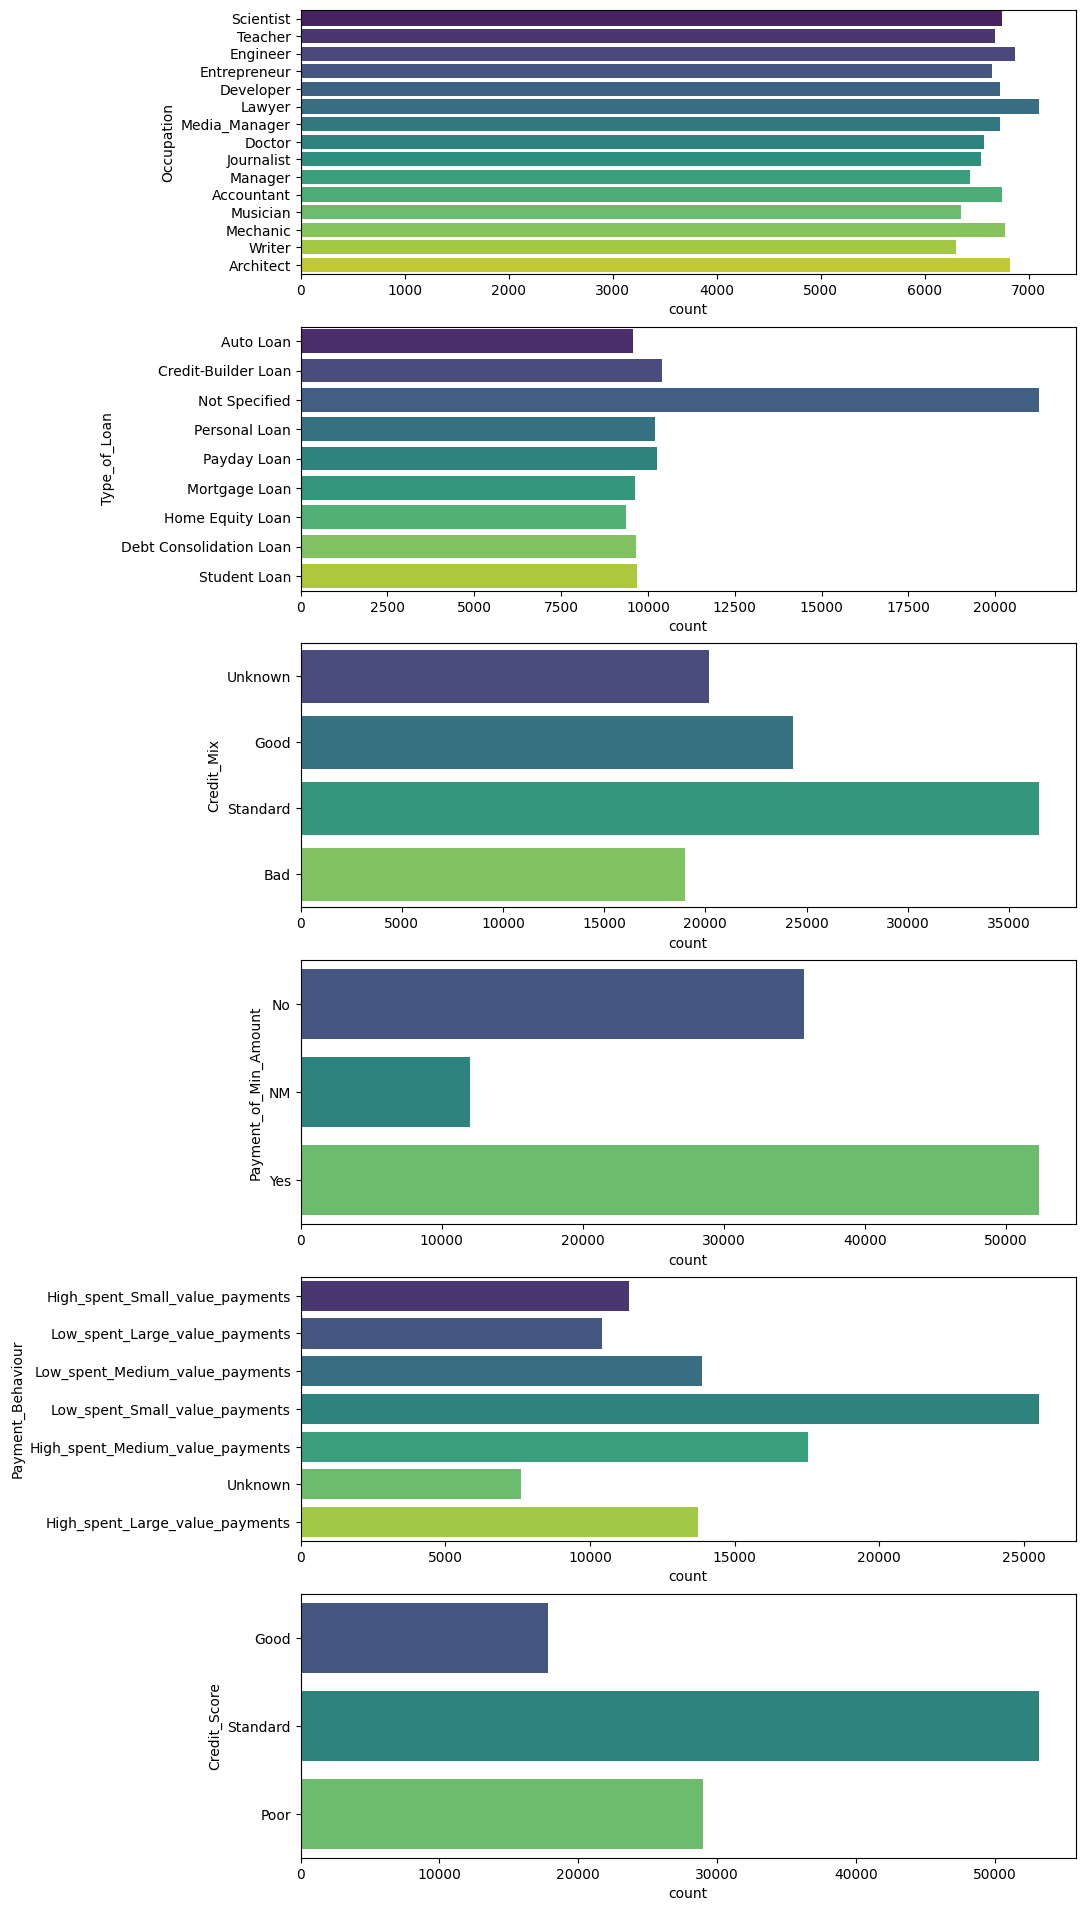

In [47]:
categorical_columns = [
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour',
    'Credit_Score'
]

fig, ax = plt.subplots(len(categorical_columns), 1,figsize=(10,24))
for i, feature in enumerate(categorical_columns):
    sns.countplot(data=cleaned_df, y=feature, ax=ax[i], hue=feature, palette='viridis', legend=False)
plt.show()

Berdasarkan visualisasi data di atas, terlihat beberapa kategori yang mendominasi dalam suatu feature. Hal ini perlu menjadi catatan tersendiri untuk kita terutama pada feature Credit_Scoring yang didominasi oleh kategori “Standard”. Fenomena ini sering disebut imbalance data yang berpotensi mengakibatkan terjadinya bias.

Oke, sekarang kita coba melihat visualisasi untuk feature numerik. Untuk melakukannya, kita akan menggunakan helper function yang kita gunakan pada contoh proyek sebelumnya.

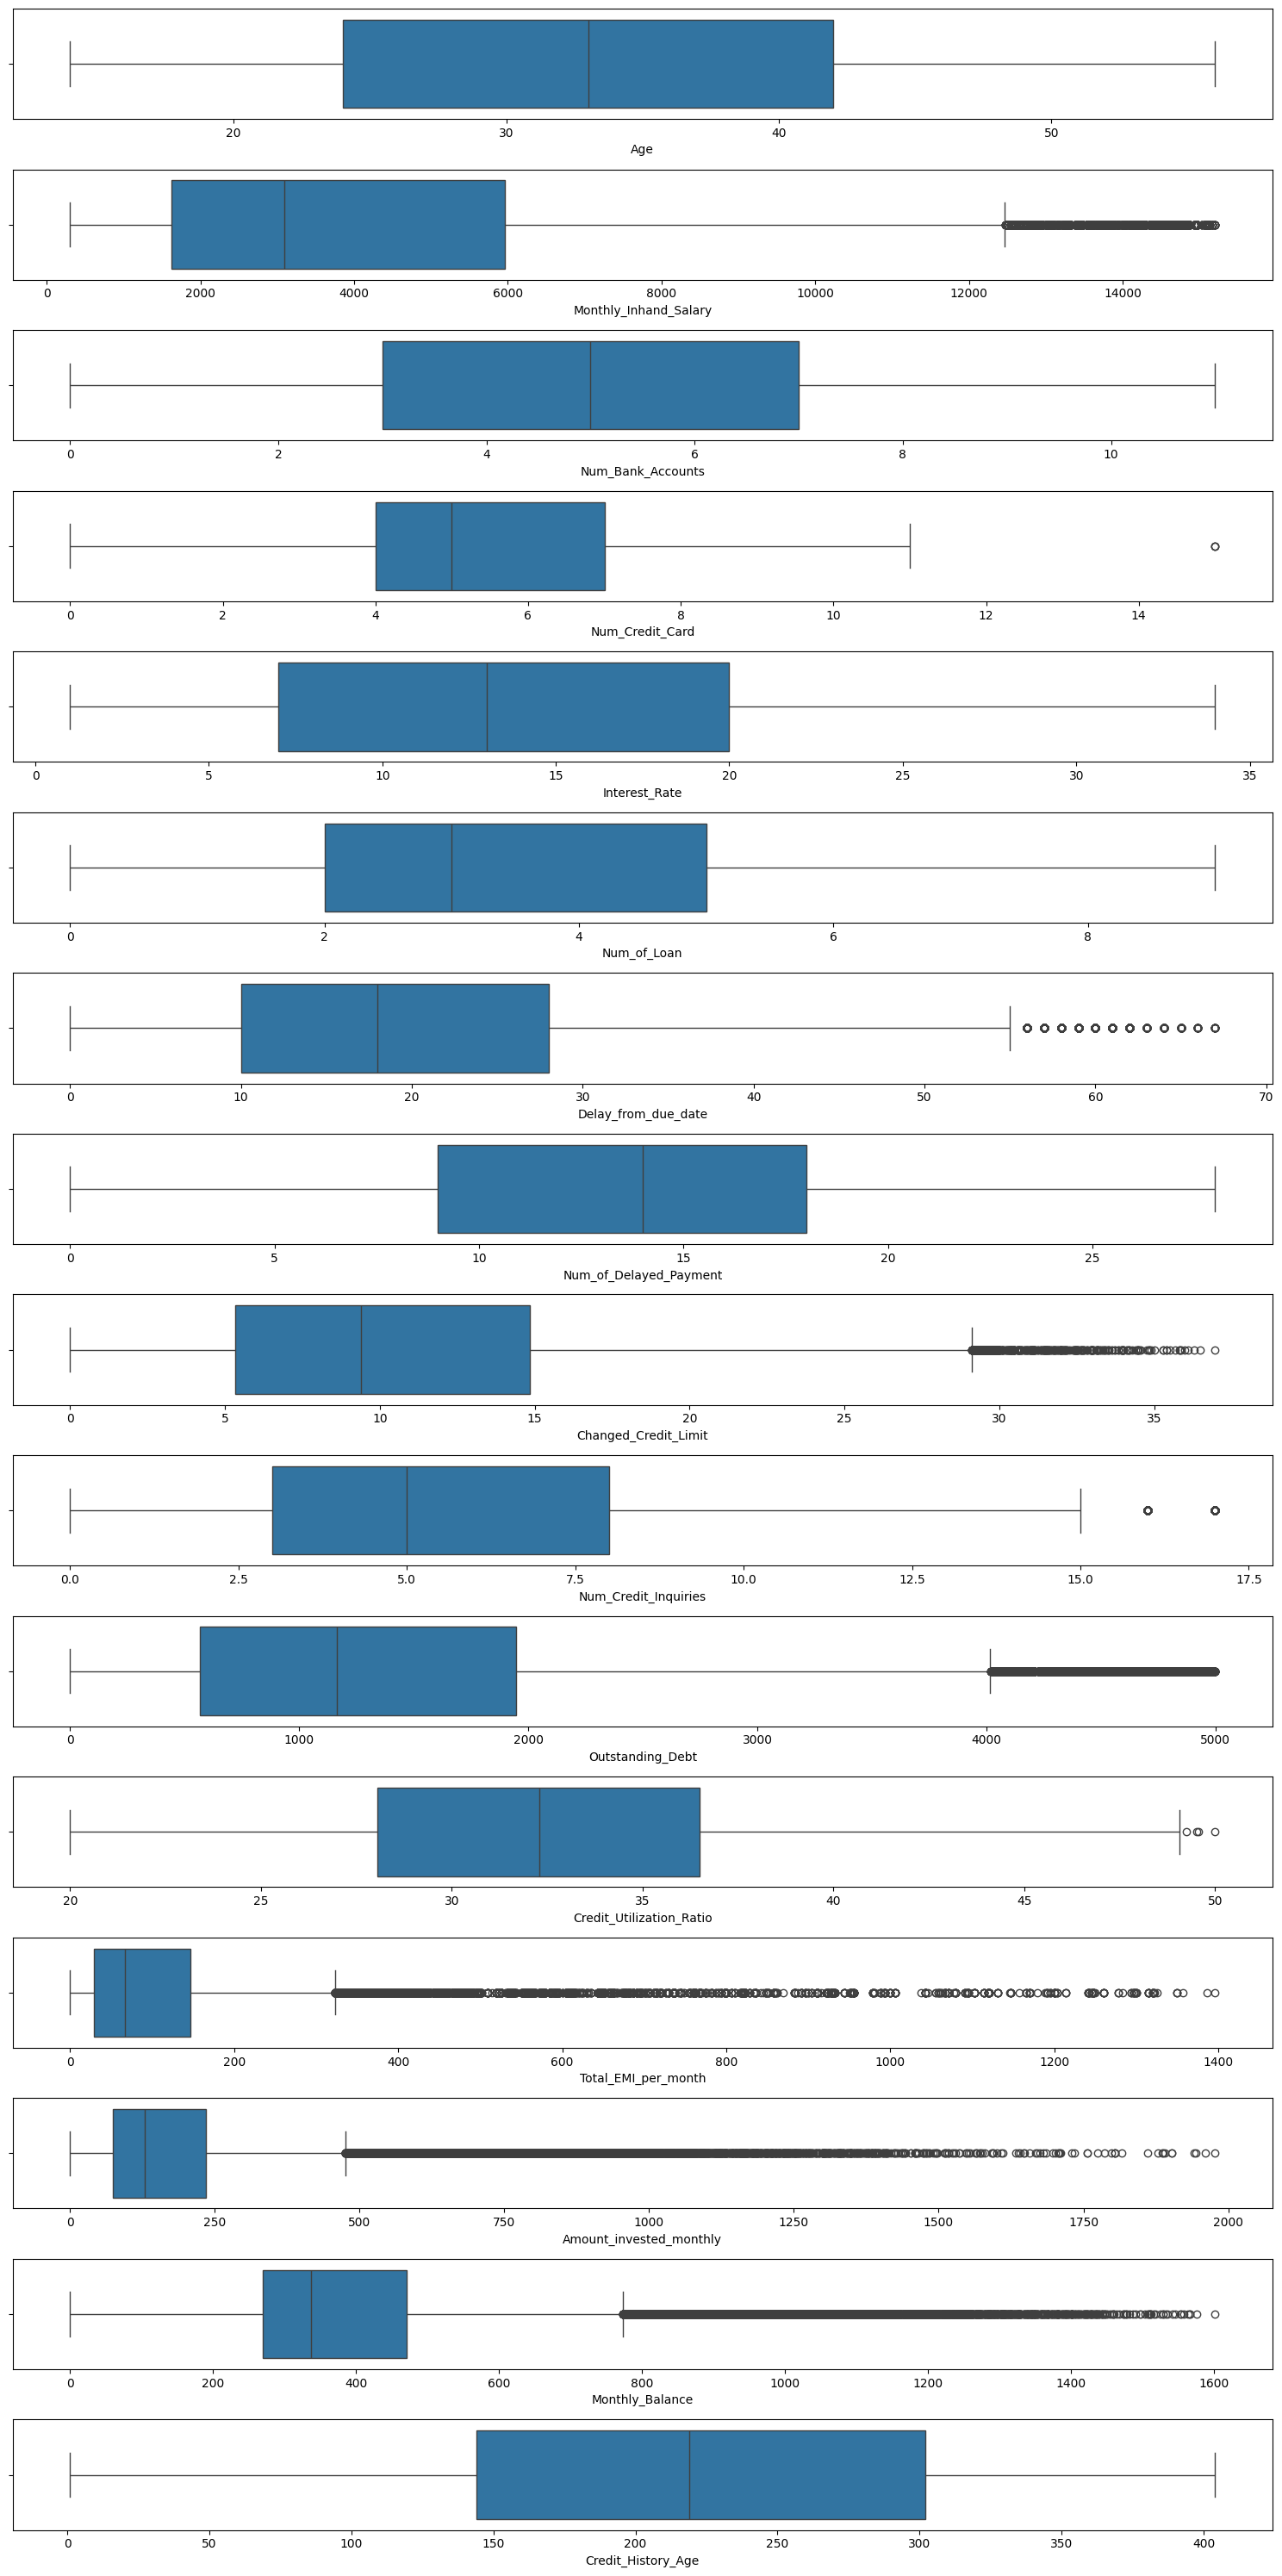

In [48]:
def numerical_dis_plot(features, df, segment_feature=None, showfliers=True):
    fig, ax = plt.subplots(len(features), 1,figsize=(15,30))
    for i, feature in enumerate(features):
        if segment_feature:
            sns.boxplot(y=segment_feature, x=feature, data=df, ax=ax[i], showfliers=showfliers)
            ax[i].set_ylabel(None)
        else:
            sns.boxplot(x=feature, data=df, ax=ax[i], showfliers=showfliers)
    plt.tight_layout()
    plt.show()

numerical_dis_plot(
    features=numerical_columns,
    df=cleaned_df
)

Pada visualisasi data di atas terlihat beberapa feature yang memiliki outlier seperti pada feature Monthly_Inhand_Salary. Hal ini terjadi karena terdapat beberapa pelanggan yang memiliki pendapatan per bulan yang jauh lebih besar ketimbang pelanggan pada umumnya. Outlier seperti ini dapat kita abaikan terlebih dahulu.

Sekarang kita coba melihat distribusi feature numerik tersebut jika dikelompokkan berdasarkan Credit_Score.

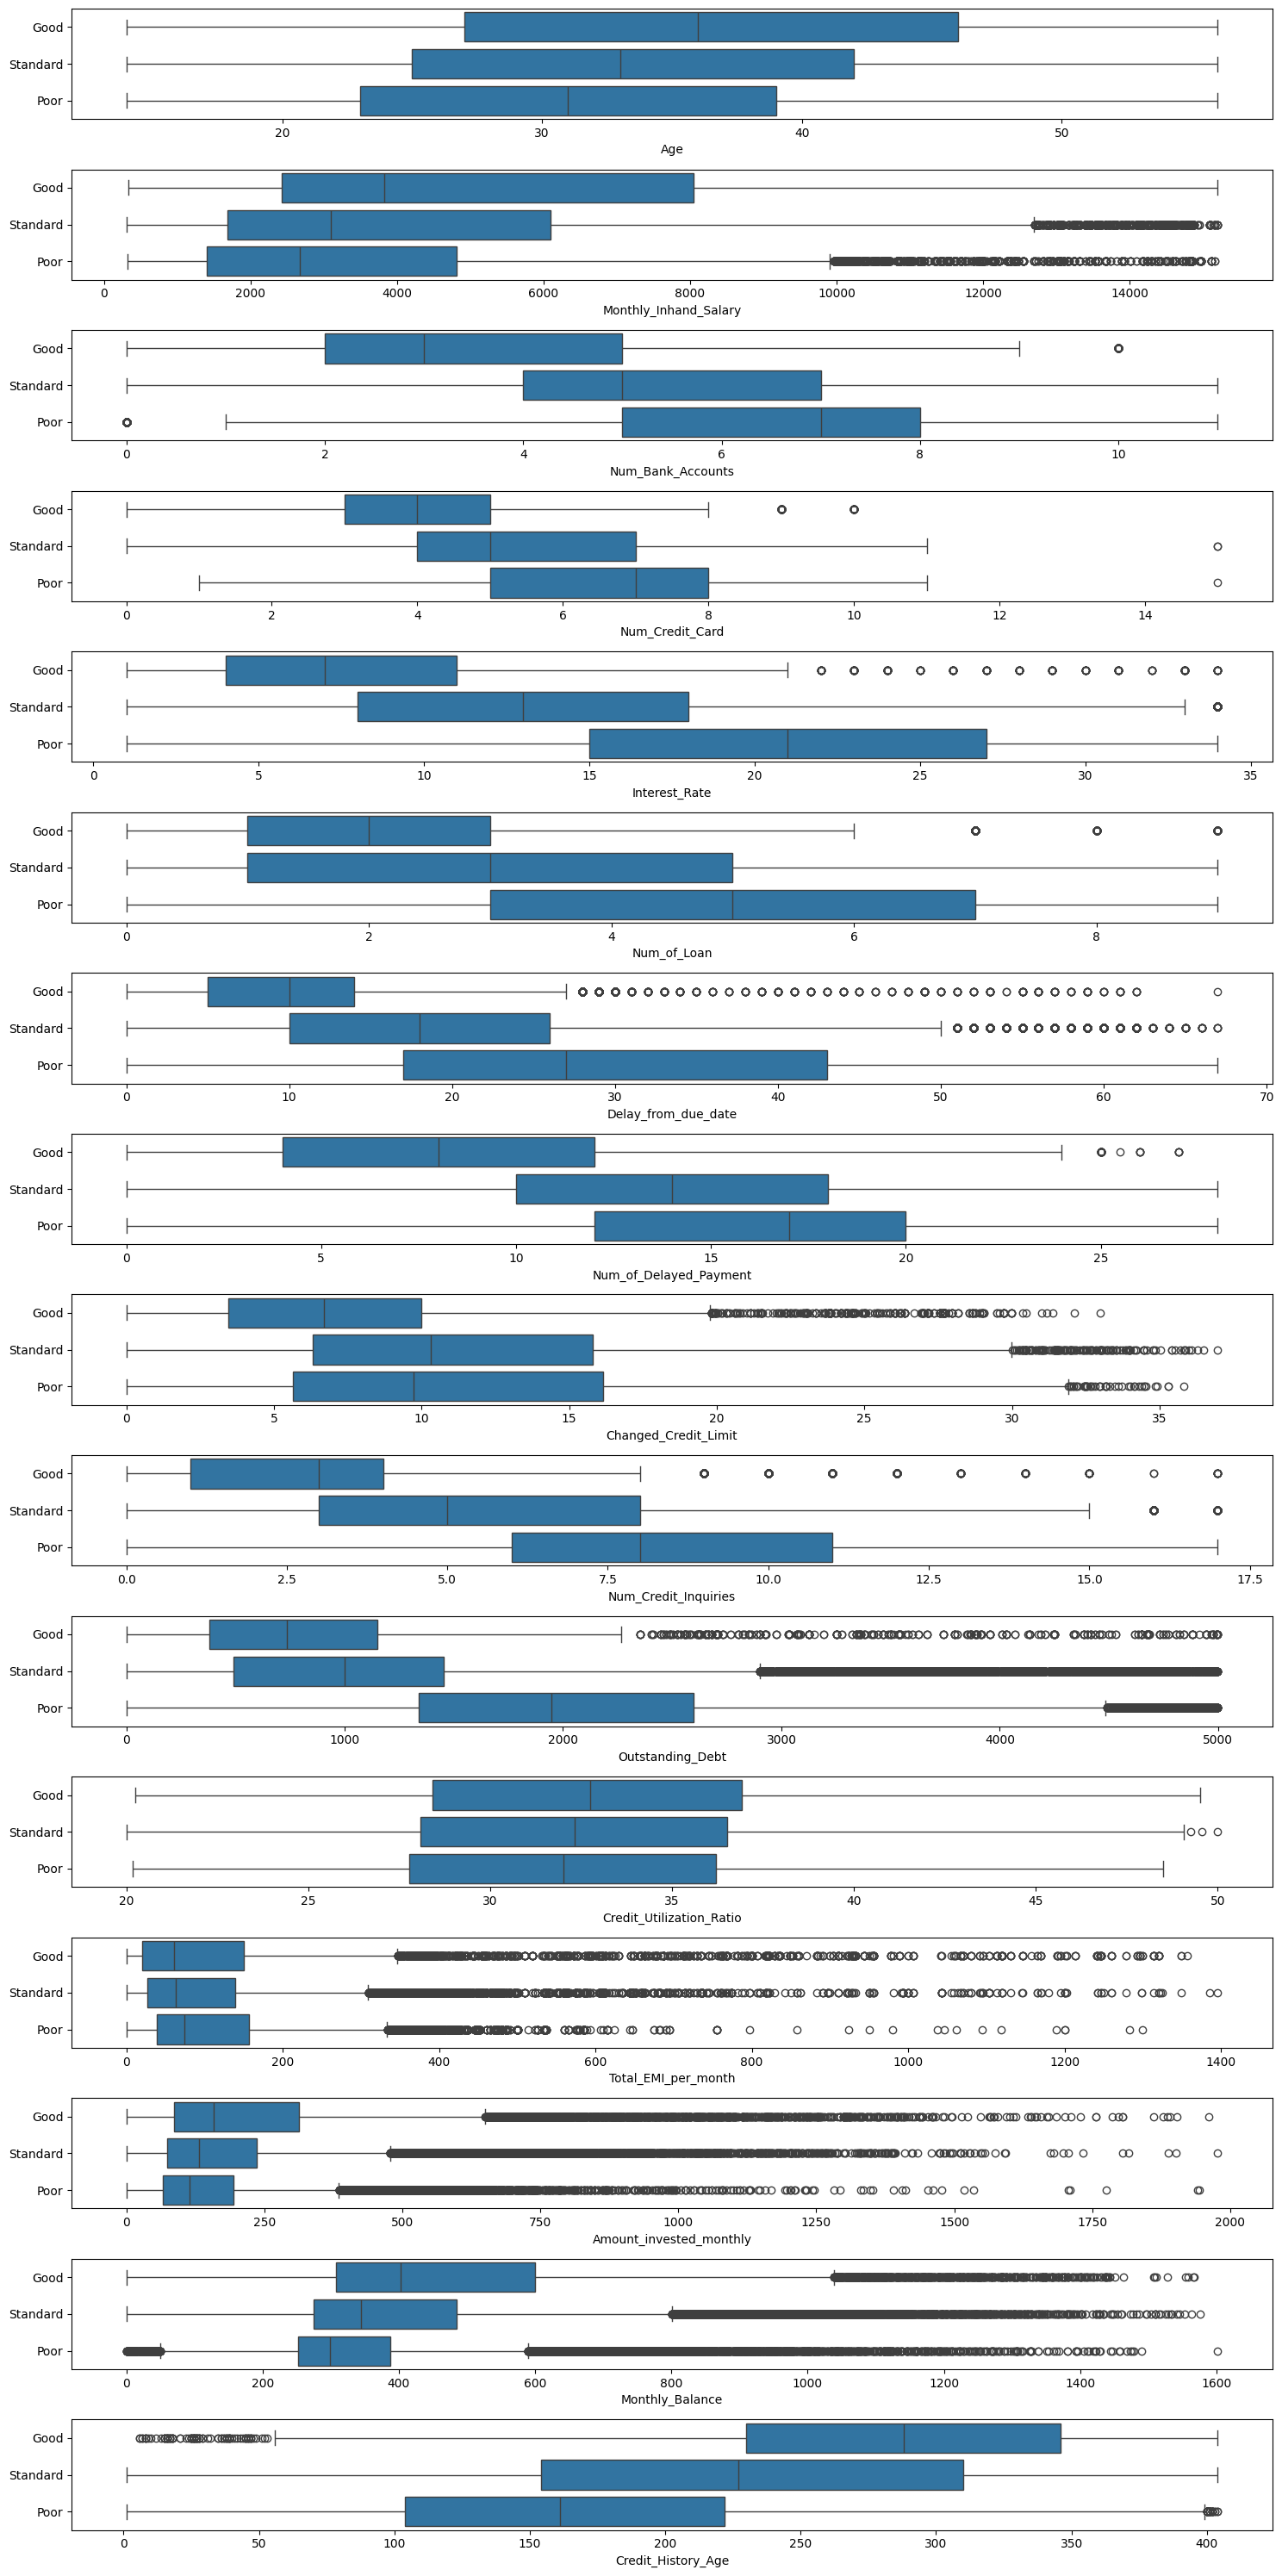

In [49]:
numerical_dis_plot(
    features=numerical_columns,
    df=cleaned_df,
    segment_feature="Credit_Score"
)

Pada visualisasi data di atas terlihat beberapa pola yang menarik seperti berikut.

1. Pelanggan yang memiliki credit score baik (Good) cenderung memiliki umur yang lebih tua. Hal ini juga sejalan dengan usia riwayat kredit dari seorang pelanggan. Semakin besar usia riwayat kredit seorang pelanggan, semakin baik pula credit score yang dimiliki oleh pelanggan tersebut.
2. Pelanggan dengan credit score yang buruk (Poor) cenderung memiliki banyak akun bank, banyak kartu kredit, jumlah utang yang banyak, serta jumlah bunga kartu kredit yang tinggi. Selain itu, mereka juga cenderung untuk melakukan penunggakan pembayaran. Hal ini terlihat pada kolom Delay_from_due_date dan Num_of_Delayed_Payment.

Beberapa insight tersebut bisa menjadi pola yang mungkin akan sangat berguna dalam proses pengembangan model nantinya. Selain itu, kita juga perlu mencatat bahwa tidak terdapat pola yang menarik pada feature Credit_Utilization_Ratio sehingga kita perlu mempertimbangkan penggunaan dari feature tersebut.

Sekarang kita coba melihat distribusi feature kategorik berdasarkan berdasarkan Credit_Score. Untuk melakukannya, Anda dapat menggunakan kode berikut.

def categorical_plot(features, df, segment_feature=Non

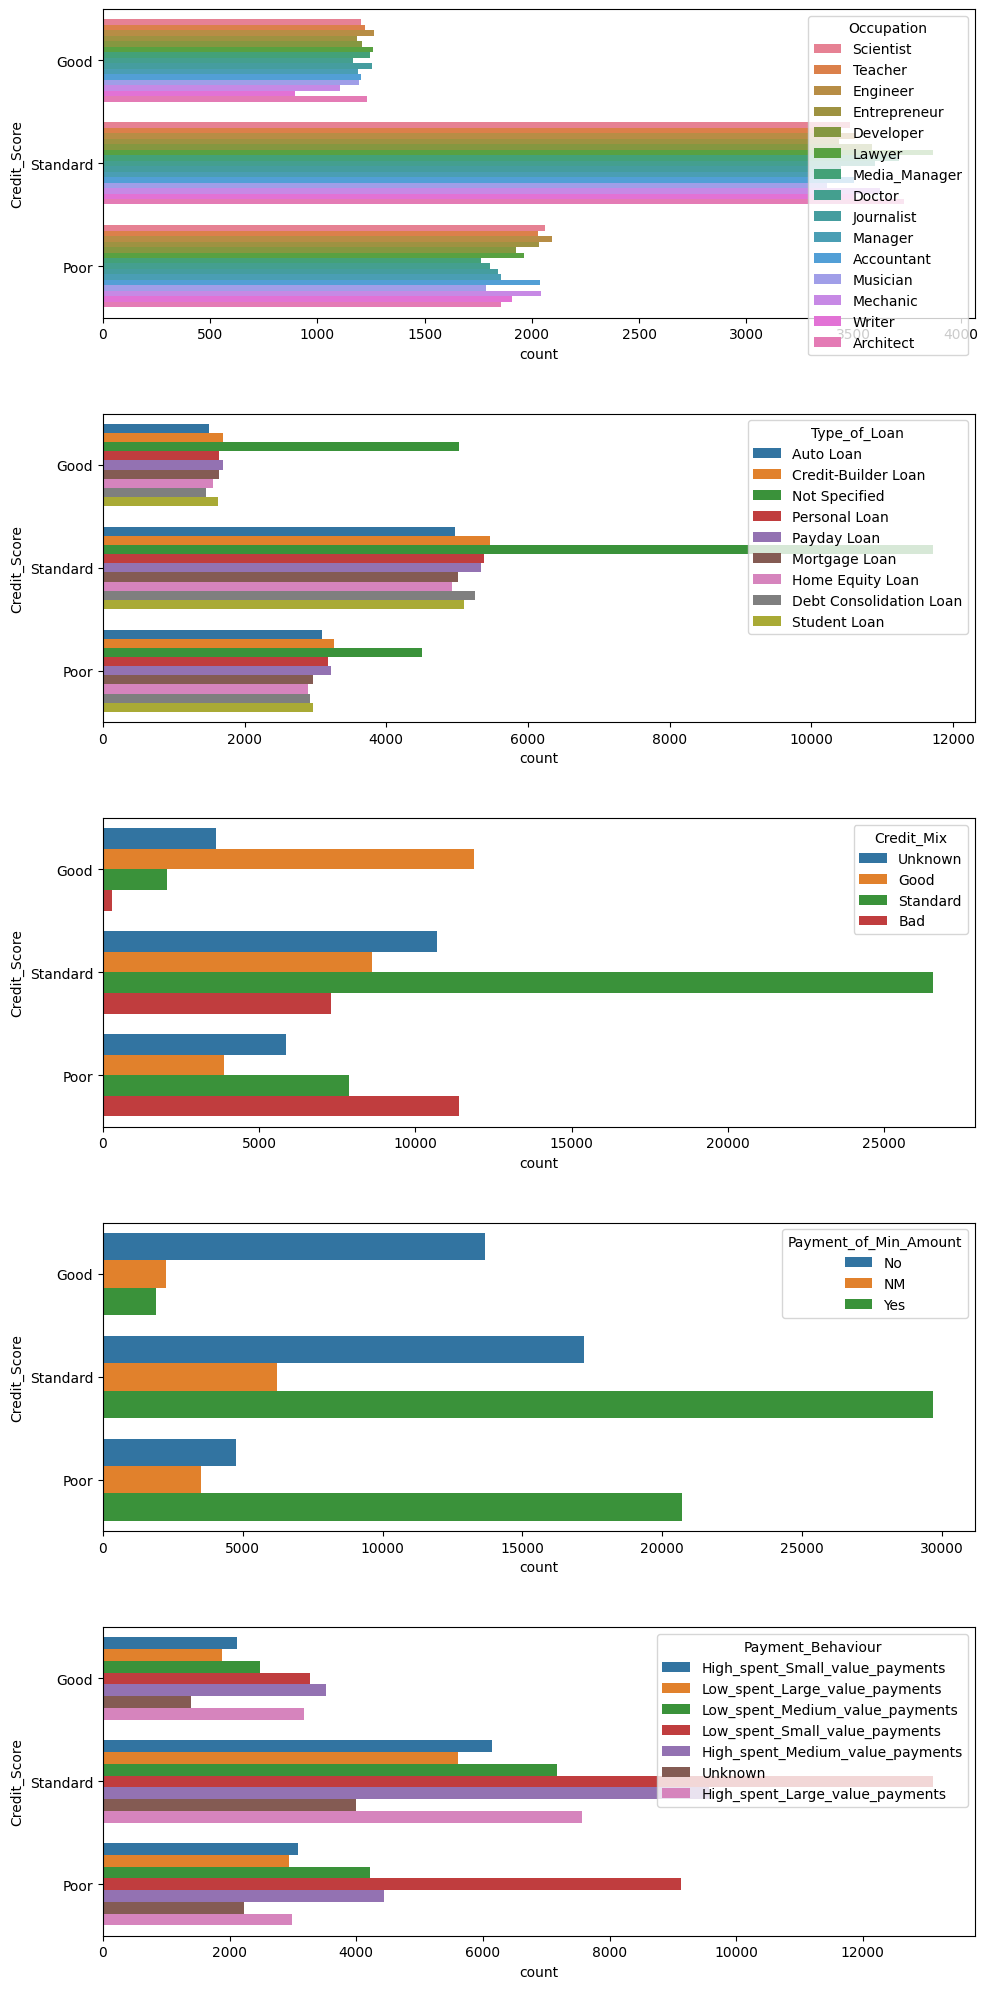

In [50]:
def categorical_plot(features, df, segment_feature=None):
    fig, ax = plt.subplots(len(features), 1,figsize=(10,20))
    for i, feature in enumerate(features):
        if segment_feature:
            sns.countplot(data=df, y=segment_feature, hue=feature, ax=ax[i])
        else:
            sns.countplot(data=df, x=feature, ax=ax[i])
    plt.tight_layout()
    plt.show()

categorical_plot(
    features=[
        'Occupation',
        'Type_of_Loan',
        'Credit_Mix',
        'Payment_of_Min_Amount',
        'Payment_Behaviour'
    ],
    df=cleaned_df,
    segment_feature="Credit_Score"
)

Pada visualisasi data di atas, terdapat beberapa pola menarik antara lain seperti di bawah ini.

1. Pelanggan dengan credit score baik (Good) memiliki kemampuan dalam mengelola kredit secara baik. Hal ini terlihat pada kolom Credit_Mix.
2. Pelanggan dengan credit score yang buruk (Poor) dan standar cenderung hanya melakukan pembayaran dengan jumlah minimum seperti yang terlihat pada kolom Payment_of_Min_Amount.
3. Pelanggan dengan credit score yang buruk (Poor) dan standar, biasanya memiliki profil “Low_spent_Small_value_payments” pada feature Payment_Behaviour.

Di sisi lain, hasil visualisasi dari feature Occupation dan Type_of_Loan tidak terdapat pola yang menarik. Oleh karena itu, kita perlu mempertimbangkan penggunaan kedua feature tersebut untuk melatih model nantinya.

Oke, sekarang kita telah menemukan pola menarik yang terdapat dalam dataset. Untuk melengkapi proses EDA ini, kita coba melihat korelasi antar feature numerik. Proses ini dapat dilakukan menggunakan contoh kode berikut.

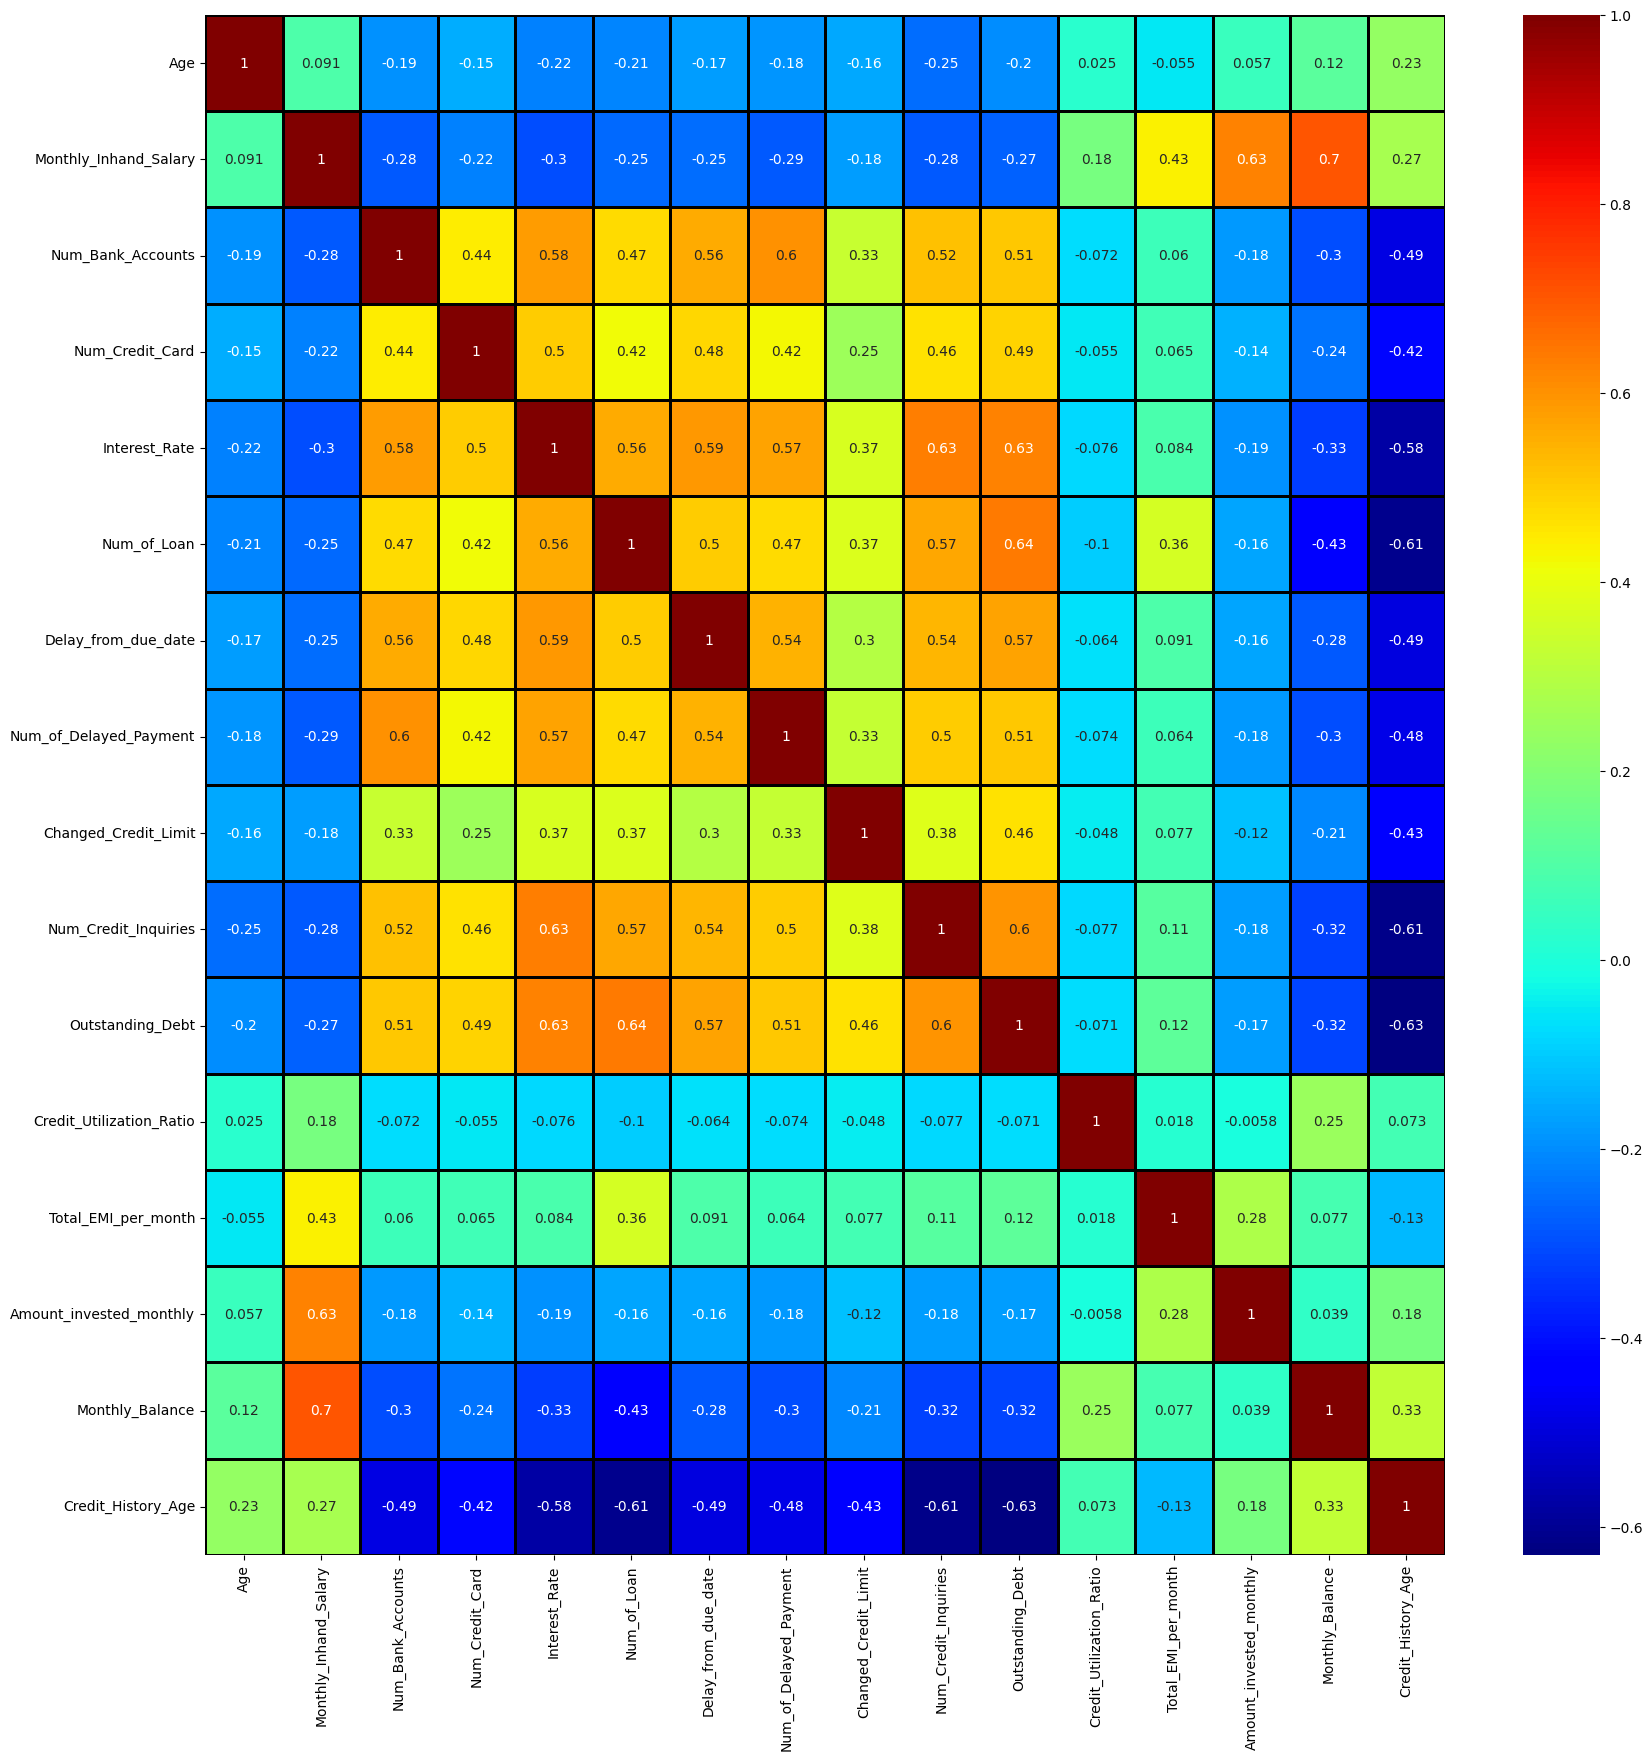

In [51]:
plt.figure(figsize=(20,20))
sns.heatmap(new_df[numerical_columns].corr(), annot=True, cmap='jet', linecolor='black', linewidth=1)
plt.show()

Pada visualisasi data di atas, terlihat beberapa fitur yang saling berkorelasi secara positif maupun negatif. Hal ini menandakan adanya multikolinearitas pada dataset yang kita miliki. Masalah multikolinearitas ini akan kita selesaikan pada tahap data preprocessing.

## Data Preproccesing


pada proyek ini kita akan melakukan beberapa tahapan untuk menyiapkan dataset sebelum digunakan untuk melatih model seperti berikut.

1. Membagi dataset menjadi dua bagian yaitu data latih dan uji.
2. Mengatasi imbalanced data dengan teknik undersampling.
3. Melakukan encoding terhadap feature kategorik dan scaling terhadap feature numerik.
4. Reduksi dimensi dan mengatasi multikolinearitas pada feature numerik.

### Train-test Split

Pada proyek yang menerapkan supervised learning, kita biasanya akan membagi dataset menjadi data latih (train) dan data uji (test). Hal ini dilakukan untuk mempertahankan sebagian data yang ada guna menguji seberapa baik generalisasi model terhadap data baru. Hal ini juga akan membantu kita dalam memilih model dengan performa terbaik dan sesuai dengan kebutuhan bisnis.



> Umumnya proporsi pembagian data latih dan uji ini adalah 80:20. Namun, ini hanyalah kebiasaan umum saja. Pada praktiknya kita perlu mempertimbangkan proporsinya berdasarkan jumlah sampel yang terdapat dalam dataset. Sebagai contoh, dataset yang kita gunakan pada proyek ini terdiri dari 100.000 sampel. Apabila menggunakan proporsi 80:20, kita akan memiliki 20.000 sampel uji. Tentunya jumlah tersebut sangatlah besar. Oleh karena itu, kita perlu menyesuaikan proporsi agar jumlah sampel uji tidak terlalu banyak. Nah, pada proyek ini, kita akan membagi dataset dengan proporsi 95:5 artinya kita akan memiliki 95.000 sampel latih dan 5.000 sampel uji.

Namun, sebelum membagi dataset ke dalam data latih dan uji, kita perlu membuang beberapa kolom yang tidak akan kita gunakan untuk melatih model. Berikut merupakan kode untuk melakukannya.



In [52]:
new_cleaned_df = cleaned_df.drop(columns=['Customer_ID', 'Month', 'Occupation', 'Type_of_Loan', 'Credit_Utilization_Ratio'], axis=1)
new_cleaned_df.head()

,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.0,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,Unknown,809.98,265.0,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,23.0,1824.843333,3.0,4.0,3.0,4.0,0.0,6.0,11.27,4.0,Good,809.98,265.0,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,23.0,1824.843333,3.0,4.0,3.0,4.0,3.0,7.0,11.27,4.0,Good,809.98,267.0,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,23.0,1824.843333,3.0,4.0,3.0,4.0,5.0,4.0,6.27,4.0,Good,809.98,268.0,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,23.0,1824.843333,3.0,4.0,3.0,4.0,6.0,6.0,11.27,4.0,Good,809.98,269.0,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good


Kode tersebut akan menghasilkan sebuah dataframe baru bernama new_cleaned_df, Nah, sekarang kita bisa membagi dataframe new_cleaned_df ke dalam dua kelompok yaitu train_df dan test_df. Proses ini akan dilakukan dengan bantuan function train_test_split() yang disediakan oleh library scikit learn seperti pada contoh kode berikut.

In [53]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(new_cleaned_df, test_size=0.05, random_state=42, shuffle=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print(train_df.shape)
print(test_df.shape)

(95000, 19)
(5000, 19)


Kode di atas akan membagi new_cleaned_df menjadi dua bagian (train_df dan test_df) dengan proporsi 95:5. Proses pembagian ini dilakukan secara acak (shuffle=True) untuk memastikan semua keadaan yang terdapat dalam dataset dapat terwakilkan dengan baik. Berikut merupakan output yang dari kode tersebut yang menunjukkan ukuran dari train_df dan test_df.

### Undersampling

Pada proses EDA sebelumnya, kita menemukan fakta bahwa feature Credit_Score dalam dataset yang kita miliki didominasi oleh kategori “Standard”. Anda dapat memvalidasinya menggunakan kode berikut.

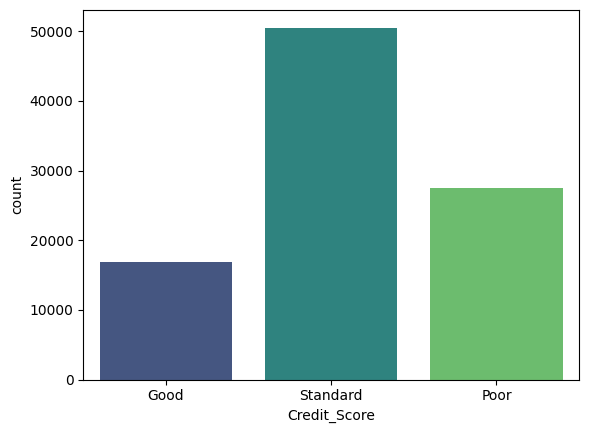

In [54]:
sns.countplot(data=train_df, x="Credit_Score", hue="Credit_Score", palette='viridis', legend=False)
plt.show()

Pada visualisasi data di atas, terlihat bahwa data latih yang kita miliki didominasi oleh kategori “Standard”. Ia menunjukkan terjadinya imbalance data dalam data latih yang kita miliki. Hal ini sangat berbahaya karena berpotensi menghasilkan bias sehingga membuat model cenderung memprediksi kelas atau kategori yang dominan (mayoritas).

Terdapat dua teknik yang umum digunakan untuk menangani imbalance data yaitu oversampling dan undersampling. Pada teknik oversampling, kita akan memperbanyak data dari kelas minoritas dengan cara membuat salinan secara acak dari data yang sudah ada hingga jumlahnya sama dengan kelas mayoritas. Berbanding terbalik dengan hal tersebut, pada teknik undersampling, kita akan mengurangi jumlah data pada kelas mayoritas secara acak sehingga jumlahnya sama dengan kelas minoritas.



> Pada proyek ini, kita akan menerapkan teknik undersampling untuk menangani imbalanced data yang terdapat dalam data latih. Hal ini dilakukan karena kita memiliki jumlah data yang sangat banyak dan ingin menghindari duplikasi data.

Nah, untuk menerapkan teknik undersampling ini, kita perlu mengetahui terlebih dahulu jumlah data dari setiap kelas. Hal ini dapat kita lakukan menggunakan kode berikut.



In [55]:
train_df.Credit_Score.value_counts()

,count
Credit_Score,
Standard,50525
Poor,27539
Good,16936




> Oke, sekarang kita telah mengetahui jumlah sampel yang terdapat pada kelas minoritas. Kita akan mengurangi jumlah sampel dari kelas “Standard” dan “Poor” sehingga jumlahnya sama dengan kelas “Good”.

Tahap berikutnya yang harus kita lakukan adalah mengelompokkan data yang mengandung kelas mayoritas dan minoritas. Anda dapat menggunakan kode berikut untuk melakukannya.



In [56]:
df_majority_1 = train_df[(train_df.Credit_Score == "Standard")]
df_majority_2 = train_df[(train_df.Credit_Score == "Poor")]
df_minority = train_df[(train_df.Credit_Score == "Good")]

Nah, setelah memisahkan data yang mengandung kelas mayoritas dan minoritas, sekarang kita bisa melakukan proses resampling (mengambil sampel dari sampel data yang sudah ada). Proses ini dilakukan menggunakan bantuan function resample() yang disediakan oleh scikit learn. Berikut merupakan contoh kode untuk melakukannya.

In [57]:
from sklearn.utils import resample

df_majority_1_undersampled = resample(df_majority_1, n_samples=16936, random_state=42)
df_majority_2_undersampled = resample(df_majority_2, n_samples=16936, random_state=42)
print(df_majority_1_undersampled.shape)
print(df_majority_2_undersampled.shape)

(16936, 19)
(16936, 19)


Pada kode di atas, kita melakukan resampling pada setiap data yang mengandung kelas mayoritas. Jumlah sampel yang diambil secara acak adalah sebanyak 16.936 sesuai dengan jumlah sampel pada kelas minoritas. Berikut merupakan keluaran dari kode tersebut.

Nah, sekarang kita tinggal menggabungkan kembali seluruh data tersebut. Selain itu, kita juga perlu memastikan data gabungan tersebut diacak menggunakan function shuffle() yang terdapat pada library scikit learn. Berikut merupakan contoh kode untuk melakukannya.

In [58]:
from sklearn.utils import shuffle

undersampled_train_df = pd.concat([df_minority, df_majority_1_undersampled]).reset_index(drop=True)
undersampled_train_df = pd.concat([undersampled_train_df, df_majority_2_undersampled]).reset_index(drop=True)
undersampled_train_df = shuffle(undersampled_train_df, random_state=42)
undersampled_train_df.reset_index(drop=True, inplace=True)
undersampled_train_df.sample(5)

,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
15562,25.0,8535.950000,6.0,5.0,6.0,0.0,21.0,20.0,11.41,3.0,Good,271.96,266.0,No,0.000000,145.174086,High_spent_Large_value_payments,894.868965,Poor
3053,41.0,2120.582500,5.0,7.0,20.0,0.0,17.0,9.0,0.87,0.0,Standard,425.01,209.0,No,0.000000,58.803409,Low_spent_Large_value_payments,423.254841,Standard
4485,22.0,1283.427500,7.0,9.0,18.0,2.0,36.0,19.0,10.09,12.0,Bad,2063.45,161.0,Yes,16.316202,85.939211,Low_spent_Small_value_payments,316.087338,Poor
30717,25.0,3655.066667,5.0,5.0,9.0,3.0,20.0,19.0,5.69,4.0,Good,1249.64,395.0,NM,104.589179,206.567784,Low_spent_Large_value_payments,324.349703,Good
14056,34.0,1817.546250,5.0,3.0,4.0,3.0,12.0,4.0,1.69,3.0,Good,390.98,191.0,No,35.398260,45.278305,High_spent_Medium_value_payments,351.078060,Good




> Untuk memvalidasi bahwa data tersebut telah balanced, kita bisa menggunakan kode berikut.



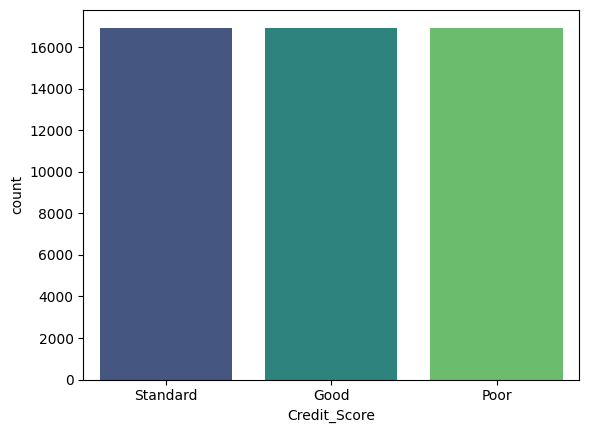

In [59]:
sns.countplot(data=undersampled_train_df, x="Credit_Score", hue="Credit_Score", palette='viridis', legend=False)
plt.show()

Yeah datanya sudah balance nih.

> Catatan: Berikut merupakan kode program yang dapat Anda gunakan jika ingin melakukan oversampling untuk mengatasi imbalanced data.

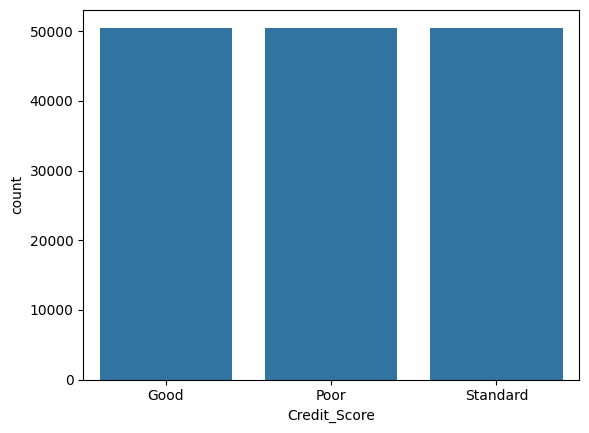

In [60]:
from sklearn.utils import resample
from sklearn.utils import shuffle

df_majority_1 = train_df[(train_df.Credit_Score == "Standard")]
df_majority_2 = train_df[(train_df.Credit_Score == "Poor")]
df_minority = train_df[(train_df.Credit_Score == "Good")]

df_majority_2_undersampled = resample(df_majority_2, n_samples=50525, random_state=42)
df_minority_undersampled = resample(df_minority, n_samples=50525, random_state=42)

oversampled_train_df = pd.concat([df_majority_1, df_majority_2_undersampled]).reset_index(drop=True)
oversampled_train_df = pd.concat([oversampled_train_df, df_minority_undersampled]).reset_index(drop=True)
oversampled_train_df = shuffle(oversampled_train_df, random_state=42)
oversampled_train_df.reset_index(drop=True, inplace=True)

sns.countplot(data=oversampled_train_df, x="Credit_Score")
plt.show()

### Encoding dan Scaling

sekarang kita masuk ke tahap berikutnya yaitu encoding dan scaling. Proses ini bertujuan untuk menyiapkan data sebelum digunakan untuk melatih model.

Encoding merupakan proses untuk membuat sebuah indeks dalam bentuk bilangan bulat yang mewakili kategori tertentu dalam sebuah feature kategorik. Proses ini perlu dilakukan karena model machine learning hanya mampu memproses data dalam bentuk numerik.

Selain melakukan encoding terhadap feature kategorik, kita juga perlu melakukan scaling pada feature numerik. Scaling merupakan proses pengubahan skala pada data numerik. Proses ini dilakukan agar seluruh feature numerik memiliki skala yang terstandarisasi. Hal ini dapat meningkatkan efisiensi dalam proses pelatihan model nantinya.

Sebelum melakukan encoding dan scaling, kita perlu memisahkan antara feature training (X) dan target (Y). Proses ini dapat Anda lakukan dengan menjalankan kode berikut.

In [61]:
X_train = undersampled_train_df.drop(columns="Credit_Score", axis=1)
y_train = undersampled_train_df["Credit_Score"]

X_test = test_df.drop(columns="Credit_Score", axis=1)
y_test = test_df["Credit_Score"]



> Oke, setelah berhasil memisahkan feature training dan target, kini saatnya kita melakukan proses encoding dan scaling terhadap feature training. Pada proyek ini, proses encoding dan scaling akan dilakukan menggunakan kedua helper function berikut.



In [62]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

def scaling(features, df, df_test=None):
    if not os.path.exists('model'):
        os.makedirs('model')
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1,1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "model/scaler_{}.joblib".format(feature))

            X_test = np.asanyarray(df_test[feature])
            X_test = X_test.reshape(-1,1)
            df_test["{}".format(feature)] = scaler.transform(X_test)
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            scaler = MinMaxScaler()
            X = np.asanyarray(df[feature])
            X = X.reshape(-1,1)
            scaler.fit(X)
            df["{}".format(feature)] = scaler.transform(X)
            joblib.dump(scaler, "model/scaler_{}.joblib".format(feature))
        return df

def encoding(features, df, df_test=None):
    if not os.path.exists('model'):
        os.makedirs('model')
    if df_test is not None:
        df = df.copy()
        df_test = df_test.copy()
        for feature in features:
            encoder = LabelEncoder()
            encoder.fit(df[feature])
            df["{}".format(feature)] = encoder.transform(df[feature])
            joblib.dump(encoder, "model/encoder_{}.joblib".format(feature))

            df_test["{}".format(feature)] = encoder.transform(df_test[feature])
        return df, df_test
    else:
        df = df.copy()
        for feature in features:
            encoder = LabelEncoder()
            encoder.fit(df[feature])
            df["{}".format(feature)] = encoder.transform(df[feature])
            joblib.dump(encoder, "model/encoder_{}.joblib".format(feature))
        return df

Function scaling() digunakan untuk melakukan proses scaling dengan metode Min-max scaling (memanfaatkan MinMaxScaler() dari scikit learn). Ia merupakan metode scaling menggunakan nilai minimum dan maksimum yang terdapat dalam sebuah feature dan mengubah data dalam feature tersebut ke dalam skala 0-1. Selain itu, function ini juga akan menyimpan object yang digunakan untuk melakukan proses scaling pada setiap feature dalam sebuah berkas dengan format .joblib. Berkas ini akan sangat berguna untuk menjalankan proses data preprocessing dalam lingkup produksi atau deployment.

Pada function encoding(), kita akan melakukan proses encoding pada seluruh feature kategorik dengan bantuan LabelEncoder() dari scikit learn. Pada function ini juga kita akan menyimpan setiap object yang digunakan untuk melakukan proses scaling pada suatu feature kategorik. Tujuannya agar proses ini dapat dilakukan dalam lingkup deployment dengan hasil yang konsisten.

Berikut merupakan contoh kode yang dapat Anda gunakan untuk menjalankan kedua helper function tersebut.

In [63]:
numerical_columns = [
    'Age',
    'Monthly_Inhand_Salary',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Credit_History_Age'
]

categorical_columns = [
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]

new_train_df, new_test_df = scaling(numerical_columns, X_train, X_test)
new_train_df, new_test_df = encoding(categorical_columns, new_train_df, new_test_df)

In [64]:
print('new_train_df after scaling and encoding:')
display(new_train_df.head())
print('\nnew_test_df after scaling and encoding:')
display(new_test_df.head())

new_train_df after scaling and encoding:


,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0.690476,0.237662,0.454545,0.636364,0.242424,0.666667,0.194030,0.392857,0.387503,0.529412,2,0.483121,0.439206,2,0.113024,0.025093,0,0.266400
1,0.190476,0.503576,0.363636,0.454545,0.030303,0.444444,0.179104,0.392857,0.171828,0.235294,1,0.289799,0.732010,1,0.111900,0.080054,0,0.451454
2,0.428571,0.090128,0.272727,0.636364,0.121212,0.444444,0.208955,0.285714,0.274322,0.117647,1,0.168241,0.918114,1,0.033189,0.021363,3,0.221049
3,0.476190,0.126136,0.454545,0.636364,0.272727,0.444444,0.194030,0.642857,0.057002,0.117647,1,0.063219,0.908189,0,0.060780,0.020599,0,0.212522
4,0.452381,0.104396,0.363636,0.454545,0.303030,0.444444,0.268657,0.000000,0.036722,0.058824,1,0.025547,0.838710,1,0.050268,0.082627,5,0.155497



new_test_df after scaling and encoding:


,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0.380952,0.227190,0.090909,0.454545,0.272727,0.000000,0.134328,0.214286,0.293779,0.000000,1,0.293737,0.702233,1,0.000000,0.027518,0,0.354085
1,0.095238,0.065183,0.727273,0.636364,0.515152,0.666667,0.268657,0.607143,0.600438,0.529412,0,0.953740,0.240695,2,0.043767,0.060208,5,0.152059
2,0.642857,0.709222,0.454545,0.181818,0.303030,0.222222,0.044776,0.000000,0.104686,0.176471,1,0.239067,0.471464,1,0.146336,0.640367,5,0.523208
3,0.500000,0.089119,0.545455,0.545455,0.939394,0.222222,0.223881,0.464286,0.285010,0.647059,2,0.509094,0.573201,2,0.019417,0.034071,5,0.229215
4,0.309524,0.482085,0.090909,0.181818,0.333333,0.444444,0.014925,0.000000,0.266922,0.235294,1,0.161826,0.615385,1,0.133093,0.058902,1,0.444993


Yey, sekarang kita telah memiliki data dengan skala yang sama dan seluruh feature kategorik telah diubah ke dalam bentuk integer. Good job!

Namun, sebelum kita masuk ke tahap berikutnya kita juga perlu melakukan encoding terhadap terhadap feature target pada data latih dan uji. Berikut merupakan contoh kode untuk melakukannya.

In [65]:
encoder = LabelEncoder()
encoder.fit(y_train)
new_y_train = encoder.transform(y_train)
joblib.dump(encoder, "model/encoder_target.joblib")

new_y_test = encoder.transform(y_test)

In [66]:
print('new_y_train after encoding:')
display(new_y_train[:5])
print('\nnew_y_test after encoding:')
display(new_y_test[:5])

new_y_train after encoding:


array([2, 0, 0, 0, 0])


new_y_test after encoding:


array([0, 1, 0, 1, 0])

Ini berarti Anda telah berhasil melakukan proses encoding terhadap feature target. Selamat!

Sekarang kita akan masuk tahap terakhir dalam proses data preprocessing yaitu menerapkan teknik PCA untuk mengurangi jumlah dimensi dan mengatasi multikolinearitas pada feature numerik. Yuk, kita lanjut!



### Principal Component Analysis (PCA)

Principal Component Analysis atau PCA merupakan salah satu teknik reduksi (pengurangan) dimensi yang umum digunakan di industri. Ia merupakan prosedur yang mengurangi jumlah fitur dengan tetap mempertahankan informasi pada data. PCA adalah teknik untuk mereduksi dimensi, mengekstraksi fitur, dan mentransformasi data dari “n-dimensional space” ke dalam sistem berkoordinat baru dengan dimensi m, di mana m lebih kecil dari n.

Teknik PCA ini, umumnya digunakan untuk mereduksi feature asli menjadi sejumlah kecil feature baru yang tidak berkorelasi linier. Feature baru tersebut disebut komponen utama (PC). Idealnya, komponen utama ini dapat menangkap sebagian besar varians (berkorelasi dengan informasi) dalam feature asli sehingga saat teknik PCA diterapkan pada suatu data, ia hanya akan menggunakan komponen utama untuk merepresentasikan data asli.

Pada visualisasi data di atas terlebih beberapa feature yang saling berkorelasi satu sama lain. Namun, kita tidak bisa melakukan PCA pada seluruh feature tersebut dalam satu proses karena terdapat beberapa feature yang hanya berkorelasi pada feature tertentu. Oleh karena itu, kita perlu mengumpulkan feature yang saling berkorelasi tersebut dan hanya melakukan PCA pada feature tersebut. Jika dilihat terdapat dua kelompok feature yang saling berkorelasi, kita dapat mengelompokkannya menggunakan kode berikut.

In [67]:
pca_numerical_columns_1 = [
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Interest_Rate',
    'Num_of_Loan',
    'Delay_from_due_date',
    'Num_of_Delayed_Payment',
    'Changed_Credit_Limit',
    'Num_Credit_Inquiries',
    'Outstanding_Debt',
    'Credit_History_Age'
]

pca_numerical_columns_2 = [
    'Monthly_Inhand_Salary',
    'Monthly_Balance',
    'Amount_invested_monthly',
    'Total_EMI_per_month'
]

Setelah mengelompokkan feature yang saling berkorelasi, kita perlu menyiapkan sebuah dataframe baru yang nantinya akan menampung hasil dari proses PCA. Berikut merupakan kode untuk melakukannya.

In [68]:
train_pca_df = new_train_df.copy().reset_index(drop=True)
test_pca_df = new_test_df.copy().reset_index(drop=True)

Oke, sekarang kita telah siap melakukan proses PCA terhadap kelompok feature pertama. Untuk melakukan proses PCA, pertama kita perlu mencari jumlah komponen utama yang paling optimal. Untuk melakukannya, Anda dapat menggunakan kode berikut.

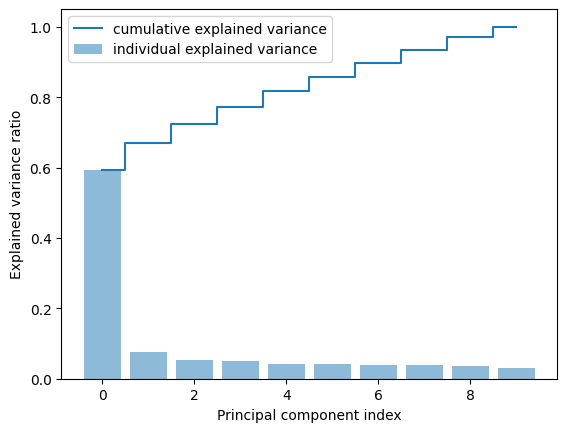

In [69]:
from sklearn.decomposition import PCA

pca = PCA(n_components=len(pca_numerical_columns_1), random_state=123)
pca.fit(train_pca_df[pca_numerical_columns_1])
princ_comp = pca.transform(train_pca_df[pca_numerical_columns_1])

var_exp = pca.explained_variance_ratio_.round(3)
cum_var_exp = np.cumsum(var_exp)

plt.bar(range(len(pca_numerical_columns_1)), var_exp, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(len(pca_numerical_columns_1)), cum_var_exp, where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.show()

Gambar di atas menunjukkan visualisasi jumlah varians untuk setiap jumlah komponen utama. Berdasarkan gambar tersebut terlihat bahwa, dengan hanya mengambil 5 komponen utama kita telah memperoleh lebih dari 80% varians. Ini berarti kita bisa mewakili seluruh kelompok feature tersebut (ada 9 feature) hanya dengan 5 komponen utama. Cukup menarik, bukan?

Nah, sekarang kita coba melakukan proses PCA kembali dengan jumlah komponen utama sebanyak 5. Kemudian, kita akan mengganti kelompok feature asli dengan 5 komponen utama dari proses PCA. Berikut merupakan kode yang digunakan untuk melakukan seluruh proses tersebut.

In [70]:
pca_1 = PCA(n_components=5, random_state=123)
pca_1.fit(train_pca_df[pca_numerical_columns_1])
joblib.dump(pca_1, "model/pca_{}.joblib".format(1))
princ_comp_1 = pca_1.transform(train_pca_df[pca_numerical_columns_1])
train_pca_df[["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"]] = pd.DataFrame(princ_comp_1, columns=["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"])
train_pca_df.drop(columns=pca_numerical_columns_1, axis=1, inplace=True)
train_pca_df.head()

,Age,Monthly_Inhand_Salary,Credit_Mix,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5
0,0.690476,0.237662,2,2,0.113024,0.025093,0,0.266400,0.215967,0.335006,0.056187,0.047697,0.147047
1,0.190476,0.503576,1,1,0.111900,0.080054,0,0.451454,-0.319090,0.112741,0.227276,0.055502,0.117496
2,0.428571,0.090128,1,1,0.033189,0.021363,3,0.221049,-0.419284,0.069814,0.232473,-0.110948,0.250861
3,0.476190,0.126136,1,0,0.060780,0.020599,0,0.212522,-0.257280,-0.237472,0.376891,-0.068669,0.012678
4,0.452381,0.104396,1,1,0.050268,0.082627,5,0.155497,-0.502601,0.073807,0.226035,-0.284458,-0.015841




> Kode tersebut akan menghasilkan data latih seperti berikut. Selain itu, ia juga menyimpan object PCA ini dalam berkas pca_1.joblib.



Oke, sekarang kita akan melakukan proses yang sama untuk kelompok data berikutnya. Berikut merupakan contoh kode untuk melakukan proses tersebut.

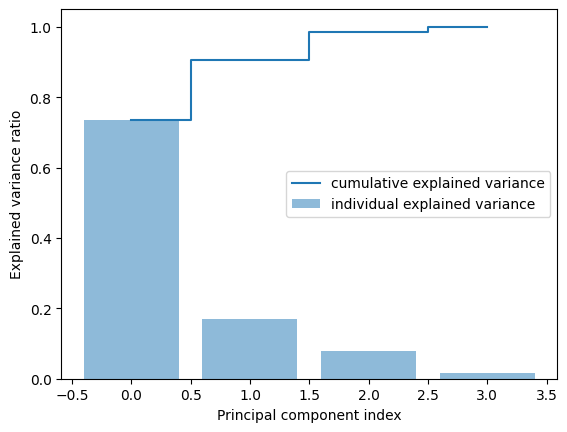

In [71]:
pca = PCA(n_components=len(pca_numerical_columns_2), random_state=123)
pca.fit(train_pca_df[pca_numerical_columns_2])
princ_comp = pca.transform(train_pca_df[pca_numerical_columns_2])

var_exp = pca.explained_variance_ratio_.round(3)
cum_var_exp = np.cumsum(var_exp)

plt.bar(range(len(pca_numerical_columns_2)), var_exp, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(len(pca_numerical_columns_2)), cum_var_exp, where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.show()

Berdasarkan grafik tersebut terlihat bahwa hanya dengan menggunakan 2 komponen utama kita telah memperoleh 90% varians. Hal ini berarti kita bisa mewakili sebagian besar informasi dari seluruh feature pada kelompok ini (ada 4 feature) hanya menggunakan dua komponen utama.

Kemudian kita dapat melakukan proses PCA kembali dengan jumlah komponen utama sebanyak 2. Lalu, mengganti kelompok feature tersebut dengan 2 komponen utama dari proses PCA. Berikut merupakan contoh kode untuk melakukannya.

In [72]:
pca_2 = PCA(n_components=2, random_state=123)
pca_2.fit(train_pca_df[pca_numerical_columns_2])
joblib.dump(pca_2, "model/pca_{}.joblib".format(2))
princ_comp_2 = pca_2.transform(train_pca_df[pca_numerical_columns_2])
train_pca_df[["pc2_1", "pc2_2"]] = pd.DataFrame(princ_comp_2, columns=["pc2_1", "pc2_2"])
train_pca_df.drop(columns=pca_numerical_columns_2, axis=1, inplace=True)
train_pca_df.head()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2
0,0.690476,2,2,0,0.215967,0.335006,0.056187,0.047697,0.147047,-0.041153,0.042993
1,0.190476,1,1,0,-0.319090,0.112741,0.227276,0.055502,0.117496,0.278922,0.109200
2,0.428571,1,1,3,-0.419284,0.069814,0.232473,-0.110948,0.250861,-0.200170,0.056832
3,0.476190,1,0,0,-0.257280,-0.237472,0.376891,-0.068669,0.012678,-0.168846,0.037691
4,0.452381,1,1,5,-0.502601,0.073807,0.226035,-0.284458,-0.015841,-0.198205,-0.034669




> Kode tersebut akan menghasilkan data latih seperti berikut serta menyimpan object PCA ini dalam berkas pca_2.joblib.



Wah, sekarang kita hanya memiliki 11 feature (awalnya terdapat 19 feature) yang akan digunakan untuk melatih model machine learning. Oh iya, jangan lupa untuk melakukan hal yang sama untuk data uji dengan kode seperti berikut.

In [73]:
test_princ_comp_1 = pca_1.transform(test_pca_df[pca_numerical_columns_1])
test_pca_df[["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"]] = pd.DataFrame(test_princ_comp_1, columns=["pc1_1", "pc1_2", "pc1_3", "pc1_4", "pc1_5"])
test_pca_df.drop(columns=pca_numerical_columns_1, axis=1, inplace=True)

test_princ_comp_1 = pca_2.transform(test_pca_df[pca_numerical_columns_2])
test_pca_df[["pc2_1", "pc2_2"]] = pd.DataFrame(test_princ_comp_1, columns=["pc2_1", "pc2_2"])
test_pca_df.drop(columns=pca_numerical_columns_2, axis=1, inplace=True)
test_pca_df.head()

,Age,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour,pc1_1,pc1_2,pc1_3,pc1_4,pc1_5,pc2_1,pc2_2
0,0.380952,1,1,0,-0.587977,0.065733,-0.240664,-0.074134,0.170567,-0.029592,0.141671
1,0.095238,0,2,5,0.760531,0.286918,-0.114280,0.250767,0.198645,-0.239788,-0.016467
2,0.642857,1,1,5,-0.441124,0.204247,-0.141170,0.030998,-0.200501,0.627704,-0.211694
3,0.500000,2,2,5,0.360242,-0.118104,-0.383711,-0.236119,-0.240762,-0.196577,0.059574
4,0.309524,1,1,1,-0.504527,0.468683,-0.080164,-0.094325,-0.195725,0.255807,0.113497


Oke, kita telah berhasil melakukan mengurangi jumlah dimensi yang awalnya berjumlah 19 feature menjadi 11 feature. Selain itu, kita juga telah mengatasi multikolinearitas yang terdapat dalam feature numerik. Ini artinya data yang kita miliki telah siap digunakan untuk melatih model machine learning.

## MODELLING

Pada proyek ini, kita ingin memanfaatkan algoritma machine learning guna mengoptimalkan proses pemeriksaan risiko kredit ketika pengajuan pinjaman berlangsung. Berdasarkan data yang kita miliki, target keluaran yang diharapkan adalah mengelompokkan pelanggan yang mengajukan pinjaman ke dalam tiga kategori yaitu Good, Standard, dan Poor.

Berdasarkan target tersebut, apakah Anda bisa menebak permasalahan machine learning apa yang akan kita selesaikan? Betul sekali, ini merupakan salah satu contoh persoalan klasifikasi lebih tepatnya ini merupakan multiclass classification. Sesuai namanya, pada multiclass classification kita akan mengelompokkan data ke dalam lebih dari dua kategori atau kelas.

Pada proyek ini, kita akan mengembangkan beberapa model menggunakan algoritma machine learning yang berbeda-beda. Kemudian, kita akan mengevaluasi performa masing-masing model lalu menentukan model mana yang memiliki performa terbaik. Nah, berikut merupakan beberapa algoritma yang akan kita gunakan.

1. Decision tree
2. Random forest
3. Gradient Boosting

Selain beberapa algoritma machine learning di atas, kita juga akan menggunakan algoritma grid search untuk melakukan mencari parameter paling optimal dari suatu model.

Apakah Anda familier dengan berbagai algoritma di atas? Jika belum, jangan khawatir karena kita akan membahas semuanya satu per satu. Yuk, kita mulai dengan algoritma grid search terlebih dahulu!

Grid Search
Bagi Anda telah terbiasa melatih model machine learning, pastinya sudah tidak asing lagi dengan istilah hyperparameters. Ia merupakan sekumpulan konfigurasi parameter yang biasa ditentukan sebelum proses training berlangsung. Hyperparameters digunakan untuk meng-custom model dan mengontrol proses training sesuai dengan dataset atau permasalahan yang ingin diselesaikan.

Pada proses pengembangan model, biasanya kita akan bereksperimen dengan berbagai konfigurasi hyperparameter. Tujuannya adalah untuk memperoleh konfigurasi yang paling optimal untuk melatih model machine learning. Proses ini sering disebut hyperparameter tuning.

Pada praktiknya, proses hyperparameter tuning ini dapat dijalankan secara manual dengan mencoba berbagai konfigurasi hyperparameter yang ada hingga diperoleh konfigurasi yang paling optimal. Alternatif lain, kita bisa menjalankan proses hyperparameter tuning secara otomatis dengan bantuan beberapa algoritma salah satunya adalah grid search.

Grid search merupakan algoritma yang memungkinkan kita untuk melakukan proses hyperparameter tuning secara otomatis. Pada prosesnya, algoritma ini akan membuat sebuah n-dimensional search space yang terbentuk dari n hyperparameter dari sebuah model. Setiap titik yang terdapat pada search space mewakili satu konfigurasi atau perpaduan dari n hyperparameter. Algoritma ini bekerja dengan mengevaluasi setiap titik yang terdapat dalam search space untuk memperoleh konfigurasi hyperparameter yang paling optimal.

Untuk menerapkan algoritma ini, kita akan menggunakan tool yang disediakan oleh scikit learn yang bernama GridSearchCV(). Ketika dipanggil, tool ini akan menerima berapa parameter seperti

1. estimator: parameter yang menampung model object;
param_grid: kumpulan hyperparameter yang akan digunakan untuk membuat grid search;
2. cv: parameter untuk mengatur proses cross validation; dan
3. n_jobs: jumlah job (pekerjaan) yang dikerjakan secara paralel. n_jobs=-1 artinya semua proses berjalan secara paralel.

**Grid Search**

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
 "penalty": ["l1","l2"],
 "C": [0.01, 0.1, 1]
}

log_model = LogisticRegression(random_state=123)

CV_lr = GridSearchCV(estimator=log_model, param_grid=param_grid, cv=5, n_jobs=-1)
CV_lr.fit(train_pca_df, new_y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=123), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l1', 'l2']})

**Pada kode di atas, kita melakukan proses hyperparameter tuning dengan grid search untuk model logistic regression. Terlihat pada bagian param_grid, kita memuat beberapa hyperparameter yang terdapat pada algoritma logistic regression seperti penalty dan C. Keduanya digunakan untuk mengatur proses regularization (teknik untuk mengurangi overfitting) yang terdapat dalam algoritma tersebut. **

**Decision Tree**

In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_model = DecisionTreeClassifier(random_state=123)

param_grid = {
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [5, 6, 7, 8],
    'criterion' :['gini', 'entropy']
}

CV_tree = GridSearchCV(estimator=tree_model, param_grid=param_grid, cv=5, n_jobs=-1)
CV_tree.fit(train_pca_df, new_y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
23 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=123),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8],
                         'max_features': ['auto', 'sqrt', 'log2']})

Untuk memperoleh hyperparameter terbaik dari proses di atas, Anda bisa menggunakan kode berikut.

In [76]:
print("best parameters: ", CV_tree.best_params_)

best parameters:  {'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt'}


Nah, itulah hyperparameter yang akan kita gunakan untuk membuat model decision tree. Berikut merupakan kode untuk membuat dan melatih model decision tree dengan hyperparameter terbaik.

In [77]:
tree_model = DecisionTreeClassifier(
    random_state=123,
    criterion='entropy',
    max_depth=6,
    max_features='sqrt'
)

tree_model.fit(train_pca_df, new_y_train)
joblib.dump(tree_model, "model/tree_model.joblib")

['model/tree_model.joblib']

**Random Forest**

In [78]:
from sklearn.ensemble import RandomForestClassifier

rdf_model = RandomForestClassifier(random_state=123)

param_grid = {
    'n_estimators': [200, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [6, 7, 8],
    'criterion' :['gini', 'entropy']
}

CV_rdf = GridSearchCV(estimator=rdf_model, param_grid=param_grid, cv=5, n_jobs=-1)
CV_rdf.fit(train_pca_df, new_y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 180.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
16 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=123),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [6, 7, 8],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 500]})

In [79]:
print("best parameters: ", CV_rdf.best_params_)

best parameters:  {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200}


In [80]:
rdf_model = RandomForestClassifier(
  random_state=123,
  max_depth=8,
  n_estimators=500,
  max_features='sqrt',
  criterion='gini',
  n_jobs=-1
)
rdf_model.fit(train_pca_df, new_y_train)
joblib.dump(rdf_model, "model/rdf_model.joblib")

['model/rdf_model.joblib']

**Gradient Boosting**

In [82]:
from sklearn.ensemble import GradientBoostingClassifier

gboost_model = GradientBoostingClassifier(random_state=123)

param_grid = {
 'max_depth': [5,8],
 'n_estimators': [200,300],
 'learning_rate': [0.01,0.1],
 'max_features': ['auto','sqrt','log2']
}

CV_gboost = GridSearchCV(estimator=gboost_model, param_grid=param_grid, cv=5, n_jobs=-1)
CV_gboost.fit(train_pca_df, new_y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=123),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [5, 8],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [200, 300]})

In [83]:
print("best parameters: ", CV_gboost.best_params_)

best parameters:  {'learning_rate': 0.1, 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 300}


In [84]:
gboost_model = GradientBoostingClassifier(
  random_state=123,
  learning_rate=0.1,
  max_depth=8,
  max_features='sqrt',
  n_estimators=300
)
gboost_model.fit(train_pca_df, new_y_train)
joblib.dump(gboost_model, "model/gboost_model.joblib")

['model/gboost_model.joblib']

## EVALUATION

In [86]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluating(y_pred, y_true):
  '''Evaluasi model'''
  labels=['Good','Poor','Standard']

  print(classification_report(y_pred=y_pred, y_true=y_true))

  cnf_matrix = confusion_matrix(y_pred=y_pred, y_true=y_true, labels=labels)
  confusion_matrix_df = pd.DataFrame(cnf_matrix, labels, labels)
  sns.heatmap(confusion_matrix_df, annot=True, annot_kws={'size': 14}, fmt='d', cmap='YlGnBu')
  plt.ylabel('True label', fontsize=15)
  plt.xlabel('Predicted label', fontsize=15)
  plt.show()

  return confusion_matrix_df

In [87]:
y_pred_test = tree_model.predict(test_pca_df)
y_pred_test = encoder.inverse_transform(y_pred_test)

              precision    recall  f1-score   support

        Good       0.49      0.82      0.62       892
        Poor       0.48      0.78      0.59      1459
    Standard       0.82      0.35      0.49      2649

    accuracy                           0.56      5000
   macro avg       0.60      0.65      0.57      5000
weighted avg       0.66      0.56      0.54      5000



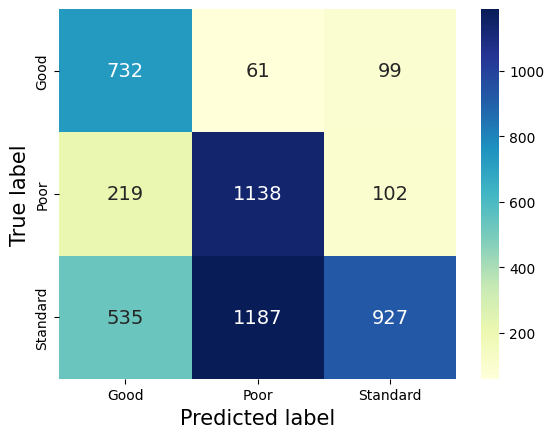

,Good,Poor,Standard
Good,732,61,99
Poor,219,1138,102
Standard,535,1187,927


In [88]:
evaluating(y_pred=y_pred_test, y_true=y_test)

              precision    recall  f1-score   support

        Good       0.50      0.83      0.62       892
        Poor       0.64      0.74      0.68      1459
    Standard       0.83      0.58      0.68      2649

    accuracy                           0.67      5000
   macro avg       0.66      0.71      0.66      5000
weighted avg       0.71      0.67      0.67      5000



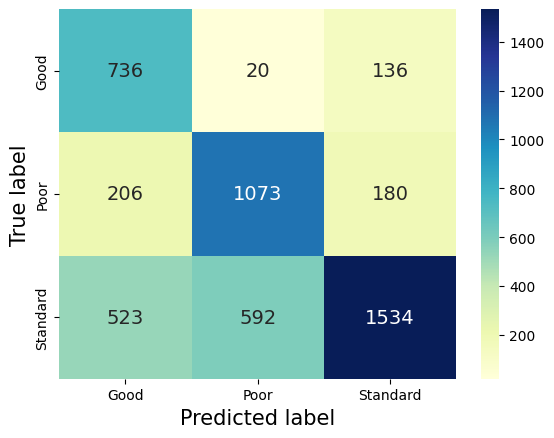

,Good,Poor,Standard
Good,736,20,136
Poor,206,1073,180
Standard,523,592,1534


In [89]:
y_pred_test = rdf_model.predict(test_pca_df)
y_pred_test = encoder.inverse_transform(y_pred_test)

evaluating(y_pred=y_pred_test, y_true=y_test)

              precision    recall  f1-score   support

        Good       0.53      0.84      0.65       892
        Poor       0.68      0.74      0.71      1459
    Standard       0.83      0.62      0.71      2649

    accuracy                           0.69      5000
   macro avg       0.68      0.73      0.69      5000
weighted avg       0.73      0.69      0.70      5000



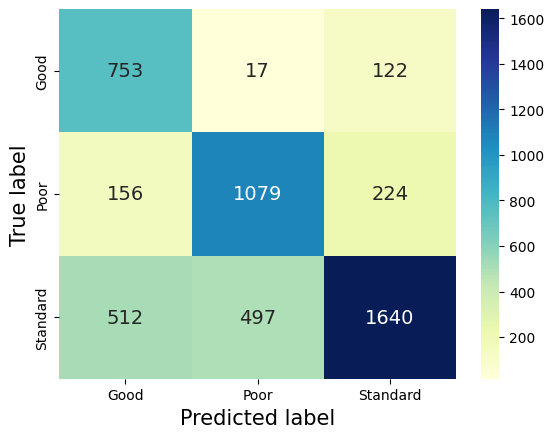

,Good,Poor,Standard
Good,753,17,122
Poor,156,1079,224
Standard,512,497,1640


In [90]:
y_pred_test = gboost_model.predict(test_pca_df)
y_pred_test = encoder.inverse_transform(y_pred_test)

evaluating(y_pred=y_pred_test, y_true=y_test)

Jika kita perhatikan, dari ketiga model tersebut belum ada model yang memiliki performa yang sangat baik dalam menangani data uji. Idealnya, pada tahap ini kita perlu memperbaiki performa dari ketiga model tersebut dengan cara meningkatkan kualitas data atau bahkan melakukan eksperimen dengan algoritma model yang lebih kompleks.

Namun, pada proyek ini kita akan tetap melanjutkannya dengan ketiga model tersebut. Oleh karena itu, kita perlu memilih salah satu dari ketiga model tersebut. Jika dilihat berdasarkan metrik accuracy, model yang memiliki performa terbaiknya adalah gradient boosting. Selain melihat dari metrik accuracy, kita juga perlu mempertimbangkan metrik yang lain. Apabila dilihat berdasarkan metrik yang lain, terlihat bahwa model dengan performa terbaik adalah gradient boosting.

Nah, selain melihat berdasarkan metrik tersebut, kita juga perlu mempertimbangkan dari segi bisnis. Untuk melakukannya, kita perlu memahami business model beserta objektif dari perusahaan tersebut. Sebagai contoh, pada proyek ini kita ingin mengidentifikasi credit scoring dari setiap pelanggan. Tentunya akan sangat bahaya bagi perusahaan jika salah mengidentifikasi orang dengan credit scoring yang buruk. Oleh karena itu, kita perlu melihat performa model dalam mengidentifikasi pelanggan yang memiliki credit scoring yang buruk. Jika dilihat dari hasil evaluasi di atas, terlihat bahwa model gradient boosting memiliki performa yang paling baik dalam mengidentifikasi pelanggan yang memiliki credit scoring yang buruk.

Jadi, berdasarkan hasil evaluasi ini, dapat disimpulkan bahwa model dengan performa terbaik adalah gradient boosting. Model inilah yang akan kita gunakan dalam membuat prototype sederhana untuk mengidentifikasi risiko kredit pelanggan. Agar dapat digunakan kembali, kita perlu menyimpan model tersebut. Berikut merupakan contoh kode untuk melakukannya.

In [91]:
joblib.dump(gboost_model, "model/gboost_model.joblib")

['model/gboost_model.joblib']

Sekilas info!

Pada proses evaluasi, selain kita melihat performa dari setiap model, kita juga memeriksa feature utama yang digunakan oleh model dalam menghasilkan sebuah prediksi. Hal ini dilakukan untuk memahami alasan dibalik setiap prediksi. Untuk mengetahui feature utama tersebut, kita bisa memanfaatkan method feature_importances_ dari sebuah model. Berikut merupakan contoh kode untuk melakukannya.

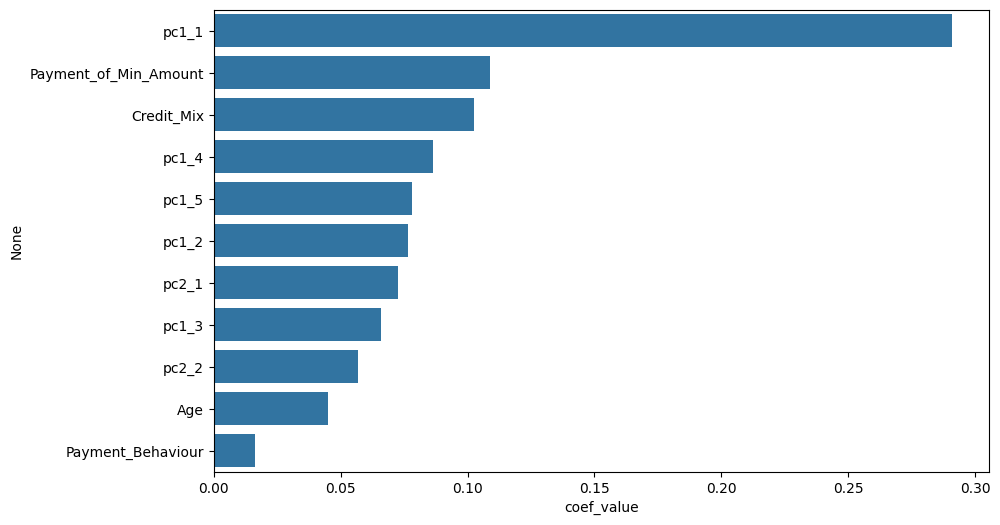

,coef_value
pc1_1,0.290903
Payment_of_Min_Amount,0.108672
Credit_Mix,0.102402
pc1_4,0.086218
pc1_5,0.078006
pc1_2,0.076595
pc2_1,0.072722
pc1_3,0.066081
pc2_2,0.056929
Age,0.045068


In [92]:
def plot_feature_importances(feature_importances, cols):
  features = pd.DataFrame(feature_importances, columns=['coef_value']).set_index(cols)
  features = features.sort_values(by='coef_value', ascending=False)
  top_features = features

  plt.figure(figsize=(10, 6))
  sns.barplot(x='coef_value', y=features.index, data=features)
  plt.show()
  return top_features

plot_feature_importances(gboost_model.feature_importances_, train_pca_df.columns)

Nah, berdasarkan visualisasi di atas terlihat bahwa model gboost_model menggunakan feature pc_1_1 sebagai fitur utama dalam menghasilkan sebuah prediksi. Informasi ini tentunya akan sangat membantu Anda dalam meningkatkan performa model.

In [93]:
import shutil
from google.colab import files

# Create a zip archive of the 'model' directory
shutil.make_archive('model', 'zip', 'model')

# Download the zip file
files.download('model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>